# Cross-Validation for Attention-Based Bi-LSTM with Data Augmentation and Without Feature Engineering

This notebook performs k-fold cross-validation on an Attention-Based Bidirectional LSTM model for Parkinson's Disease detection using handwriting dynamics data. The pipeline includes comprehensive data augmentation, feature engineering, and multi-level evaluation (sequence, file, and person).

# Configuration and Setup

Setting up the environment for reproducible experiments:
- **Seed Configuration**: Fixed random seed (42) across all libraries (Python, NumPy, TensorFlow)
- **Deterministic Operations**: TensorFlow configured for deterministic GPU operations
- **Channel Selection**: Five key handwriting dynamics features (Fingergrip, Axial Pressure, Tilt X/Y/Z)
- **Environment Variables**: PYTHONHASHSEED and TF_DETERMINISTIC_OPS set for consistency

In [1]:
# =====================================
# CONFIGURATION AND SETUP
# =====================================

import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from sklearn.utils import class_weight
import pickle
from scipy.stats import entropy

# SET SEEDS FOR REPRODUCIBILITY
seed = 42

# Must be set before importing TensorFlow
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import tensorflow as tf

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Set pandas display options
pd.set_option('display.max_columns', None)

# Updated channel names (excluding Microphone)
channel_names = [
    "Fingergrip", "Axial_Pressure",
    "Tilt_X", "Tilt_Y", "Tilt_Z"
]

# Data Loading

Loading preprocessed training and testing datasets with applied augmentation and feature engineering:
- **Training Data**: Augmented samples with engineered features from handwriting dynamics
- **Testing Data**: Held-out test set for final model evaluation
- **Data Format**: Pickle files containing windowed sequences with labels and metadata
- **Features Included**: Statistical features, mass calculations, delta values, and temporal patterns

In [2]:
# =====================================
# LOAD THE CLEAN, SPLIT DATA
# =====================================

df_train = pd.read_pickle('C:/Users/raydo/DATASCI_17_Thesis/Pipelines/With Aug and without FE/df_train.pkl')
df_test = pd.read_pickle('C:/Users/raydo/DATASCI_17_Thesis/Pipelines/With Aug and without FE/df_test.pkl')

print("Clean data loaded.")
print(f"Training samples: {len(df_train)}")
print(f"Testing samples: {len(df_test)}")

Clean data loaded.
Training samples: 1244
Testing samples: 80


# Model Dependencies

Importing essential libraries for deep learning model construction and evaluation:
- **TensorFlow/Keras**: Neural network architecture (Bi-LSTM, Attention layers)
- **Optimization**: Adam optimizer with learning rate scheduling and regularization
- **Validation**: StratifiedKFold for person-level cross-validation
- **Metrics**: Classification reports, confusion matrices, ROC/PR curves, AUC scores

In [3]:
# =====================================
# IMPORTS FOR MODELING
# =====================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, auc
import seaborn as sns
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.losses import BinaryCrossentropy


# Sequence Generation and Normalization

Creating overlapping temporal sequences from windowed data for LSTM processing:
- **Sequence Length**: 20 consecutive windows per sequence
- **Step Size**: 10 windows overlap to capture temporal continuity
- **Feature Selection**: Excluding metadata columns (label, file_name, Person_ID, demographics)
- **Standardization**: StandardScaler applied across all features to normalize value ranges
- **Output Shape**: (n_sequences, 20, n_features) for Bi-LSTM input

In [4]:
# =====================================
# CREATE SEQUENCES OF WINDOWS
# =====================================

def create_sequences(df, sequence_length, step_size):
    sequences = []
    labels = []
    file_names = []
    person_ids = []
    print(f"Creating sequences of length {sequence_length} with step {step_size}...")
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        signal = row['signal']
        label = row['label']
        file_name = row['file_name']
        person_id = row['Person_ID_Number']
        if len(signal) < sequence_length:
            continue
        for start in range(0, len(signal) - sequence_length + 1, step_size):
            end = start + sequence_length
            sequence = signal[start:end, :]
            
            sequences.append(sequence)
            labels.append(label)
            file_names.append(file_name)
            person_ids.append(person_id)
    return np.array(sequences), np.array(labels), np.array(file_names), np.array(person_ids)

SEQUENCE_LENGTH = 20
STEP_SIZE = 10

X_train_seq, y_train_seq, sequence_file_names_train, sequence_person_ids_train = create_sequences(df_train, SEQUENCE_LENGTH, STEP_SIZE)
X_test_seq, y_test_seq, sequence_file_names_test, sequence_person_ids_test = create_sequences(df_test, SEQUENCE_LENGTH, STEP_SIZE)

print("\n--- Data Shapes After Sequencing ---")
print(f"X_train sequences shape: {X_train_seq.shape}")
print(f"y_train sequences shape: {y_train_seq.shape}")
print(f"X_test sequences shape: {X_test_seq.shape}")

n_sequences_train = X_train_seq.shape[0]
n_sequences_test = X_test_seq.shape[0]
n_timesteps = X_train_seq.shape[1]
n_channels = X_train_seq.shape[2]

X_train_reshaped = X_train_seq.reshape(-1, n_channels)
X_test_reshaped = X_test_seq.reshape(-1, n_channels)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

X_train_final = X_train_scaled.reshape(n_sequences_train, n_timesteps, n_channels)
X_test_final = X_test_scaled.reshape(n_sequences_test, n_timesteps, n_channels)

print("\n--- Final Data Shapes for LSTM Model ---")
print(f"Final X_train shape: {X_train_final.shape}")
print(f"Final X_test shape: {X_test_final.shape}")

Creating sequences of length 20 with step 10...


100%|██████████| 1244/1244 [00:01<00:00, 1001.72it/s]


Creating sequences of length 20 with step 10...


100%|██████████| 80/80 [00:00<00:00, 498.22it/s]



--- Data Shapes After Sequencing ---
X_train sequences shape: (1721684, 20, 5)
y_train sequences shape: (1721684,)
X_test sequences shape: (134080, 20, 5)

--- Final Data Shapes for LSTM Model ---
Final X_train shape: (1721684, 20, 5)
Final X_test shape: (134080, 20, 5)


# Model Architecture: Attention-Based Bi-LSTM

Building a deep learning model that combines bidirectional temporal processing with attention mechanisms:
- **Bi-LSTM Layer**: 64 units capturing forward and backward temporal dependencies
- **Attention Mechanism**: Custom layer computing weighted importance of time steps
- **Regularization**: L2 regularization (0.0001) and Dropout (0.4) to prevent overfitting
- **Dense Layer**: 16-unit fully connected layer with ReLU activation
- **Output**: Sigmoid activation for binary classification (Parkinson's vs. Control)
- **Optimization**: Adam optimizer with binary cross-entropy loss

In [5]:
# =====================================
# MODEL: BiLSTM + Attention
# =====================================

class Attention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(1,), initializer="zeros")
        super(Attention, self).build(input_shape)
    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

def create_bilstm_model(input_shape):
    inputs = Input(shape=input_shape)

    x = Bidirectional(
        LSTM(64, return_sequences=True, kernel_regularizer=l2(0.0001))
    )(inputs)
    x = Dropout(0.4)(x)
    x = Attention()(x)
    x = Dense(16, activation='relu', kernel_regularizer=l2(0.0001))(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.0001),
        metrics=['accuracy']
    )
    return model

# K-Fold Cross-Validation with Multi-Level Evaluation

Performing stratified 4-fold cross-validation with person-level splitting and comprehensive evaluation:
- **Stratification**: Person-level splits ensuring no data leakage between train/validation
- **Training Configuration**: Early stopping (patience=2), learning rate reduction, 100 max epochs
- **Multi-Level Metrics**: Evaluation at three granularities:
  - **Sequence-Level**: Individual sequence predictions
  - **File-Level**: Averaged predictions per handwriting sample
  - **Person-Level**: Averaged predictions per participant
- **Visualizations**: Learning curves, confusion matrices, ROC curves, and precision-recall curves for each fold
- **Summary Statistics**: Mean ± SD for accuracy, AUC, precision, recall, and F1-score across all folds


Starting 4-fold cross-validation...

--- Fold 1 ---
Epoch 1/100
19434/19434 [==============================] - 381s 19ms/step - loss: 0.4617 - accuracy: 0.7919 - val_loss: 1.1020 - val_accuracy: 0.4681 - lr: 1.0000e-04
Epoch 2/100
19434/19434 [==============================] - 395s 20ms/step - loss: 0.4005 - accuracy: 0.8275 - val_loss: 1.1141 - val_accuracy: 0.4766 - lr: 1.0000e-04
Epoch 3/100
19434/19434 [==============================] - 398s 20ms/step - loss: 0.3818 - accuracy: 0.8373 - val_loss: 1.0839 - val_accuracy: 0.4907 - lr: 1.0000e-04
Epoch 4/100
19434/19434 [==============================] - 401s 21ms/step - loss: 0.3683 - accuracy: 0.8443 - val_loss: 1.1567 - val_accuracy: 0.4882 - lr: 1.0000e-04
Epoch 5/100
19434/19434 [==============================] - ETA: 0s - loss: 0.3565 - accuracy: 0.8501Restoring model weights from the end of the best epoch: 3.

Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
19434/19434 [==============================

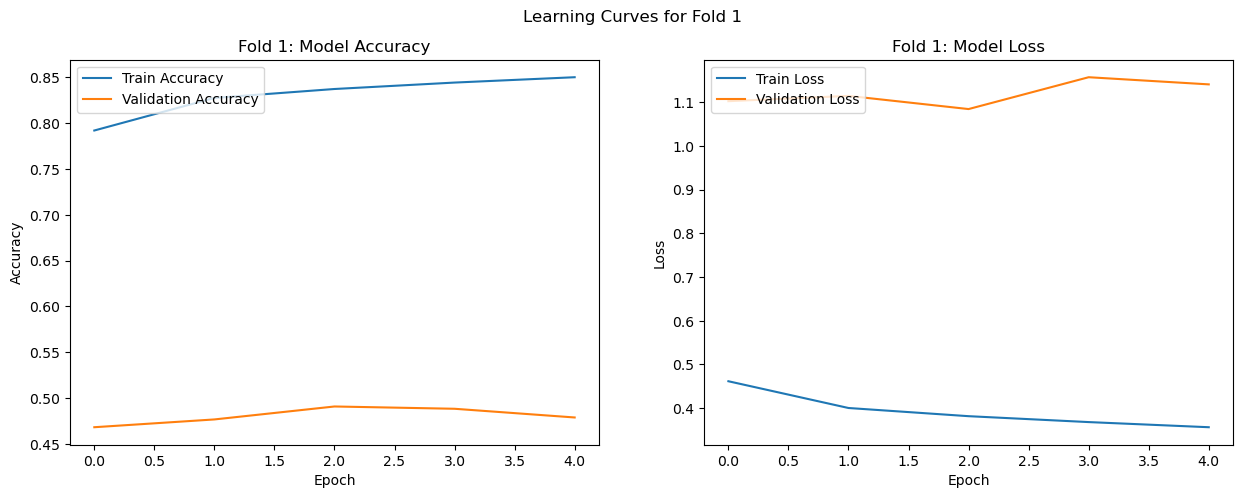

14936/14936 [==============================] - 73s 5ms/step

Sequence-level Accuracy = 0.4907

Sequence-level Classification Report:
              precision    recall  f1-score   support

           0     0.3972    0.6680    0.4982    180866
           1     0.6544    0.3827    0.4830    297071

    accuracy                         0.4907    477937
   macro avg     0.5258    0.5254    0.4906    477937
weighted avg     0.5571    0.4907    0.4887    477937



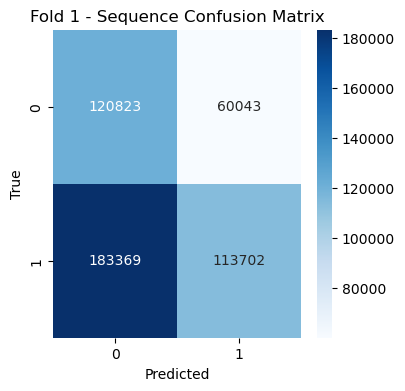

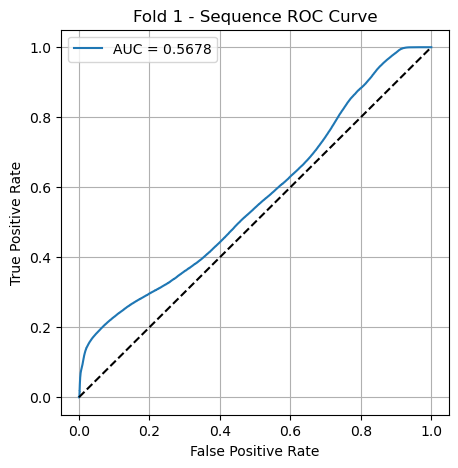

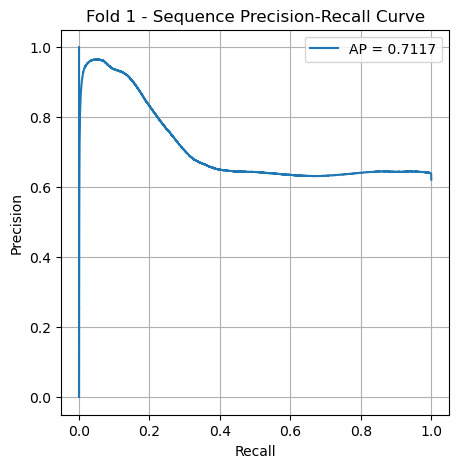


File-level Accuracy = 0.5333

File-level Classification Report:
              precision    recall  f1-score   support

           0     0.5000    0.6250    0.5556        56
           1     0.5800    0.4531    0.5088        64

    accuracy                         0.5333       120
   macro avg     0.5400    0.5391    0.5322       120
weighted avg     0.5427    0.5333    0.5306       120



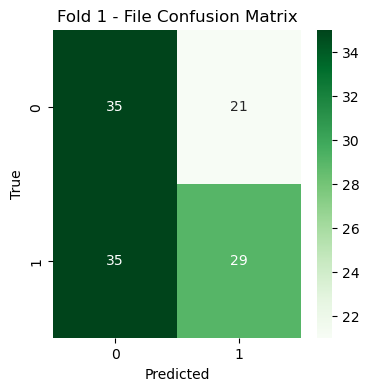

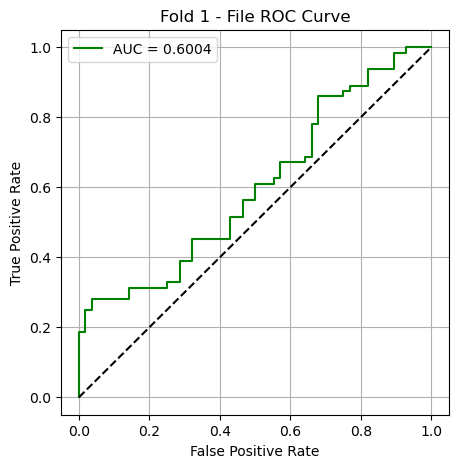

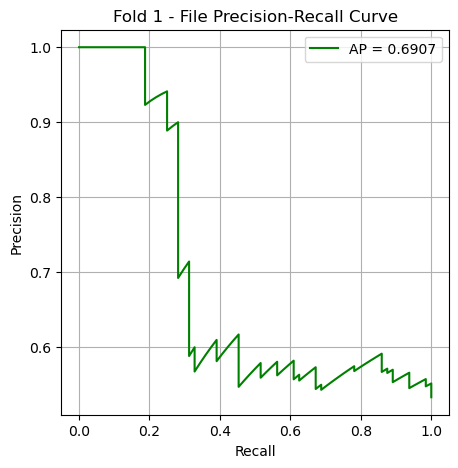


Person-level Accuracy = 0.6154

Person-level Classification Report:
              precision    recall  f1-score   support

           0     0.6250    0.7143    0.6667         7
           1     0.6000    0.5000    0.5455         6

    accuracy                         0.6154        13
   macro avg     0.6125    0.6071    0.6061        13
weighted avg     0.6135    0.6154    0.6107        13



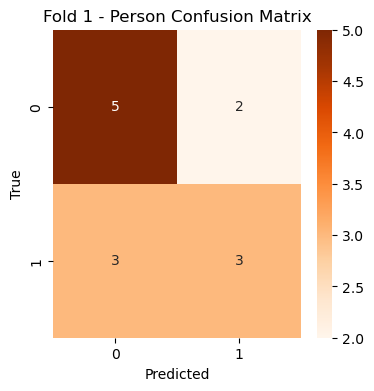

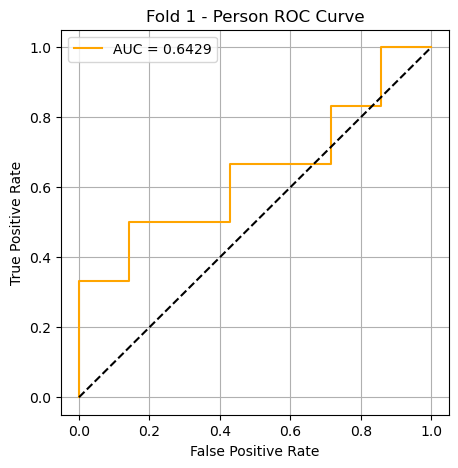

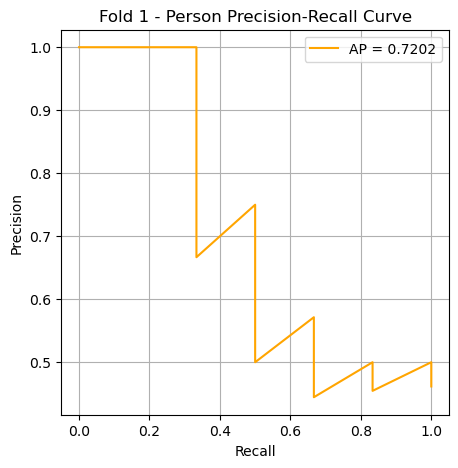


--- Fold 2 ---
Epoch 1/100
19345/19345 [==============================] - 396s 20ms/step - loss: 0.4670 - accuracy: 0.7762 - val_loss: 1.3371 - val_accuracy: 0.5215 - lr: 1.0000e-04
Epoch 2/100
19345/19345 [==============================] - 391s 20ms/step - loss: 0.4076 - accuracy: 0.8167 - val_loss: 1.4861 - val_accuracy: 0.4839 - lr: 1.0000e-04
Epoch 3/100
19343/19345 [============================>.] - ETA: 0s - loss: 0.3841 - accuracy: 0.8295Restoring model weights from the end of the best epoch: 1.

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
19345/19345 [==============================] - 395s 20ms/step - loss: 0.3841 - accuracy: 0.8295 - val_loss: 1.5555 - val_accuracy: 0.5072 - lr: 1.0000e-04
Epoch 3: early stopping

✅ Model saved to: saved_cv_models\fold_2_model.h5


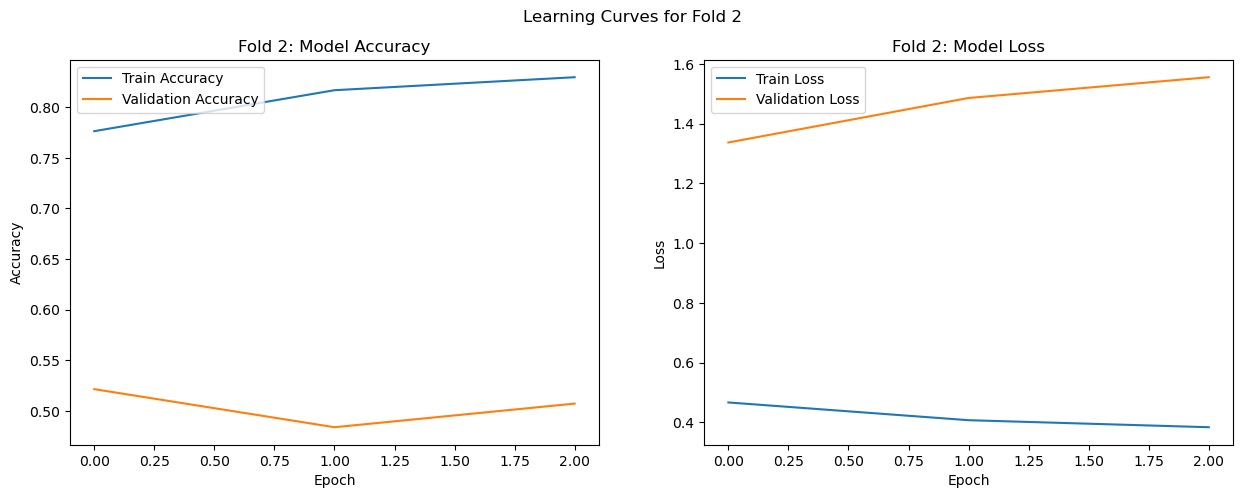

15114/15114 [==============================] - 67s 4ms/step

Sequence-level Accuracy = 0.5215

Sequence-level Classification Report:
              precision    recall  f1-score   support

           0     0.4273    0.6302    0.5093    190567
           1     0.6521    0.4508    0.5331    293068

    accuracy                         0.5215    483635
   macro avg     0.5397    0.5405    0.5212    483635
weighted avg     0.5635    0.5215    0.5237    483635



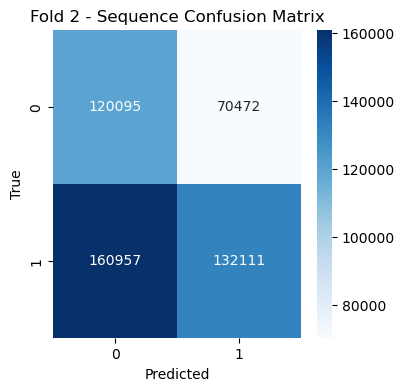

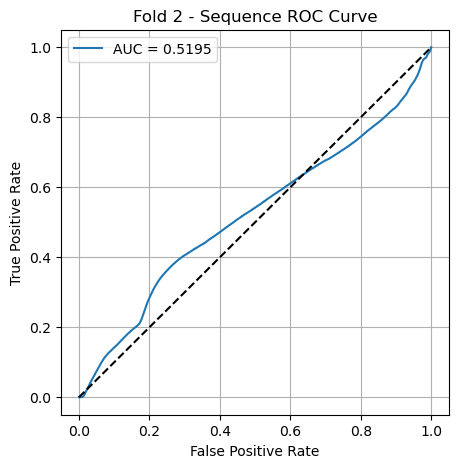

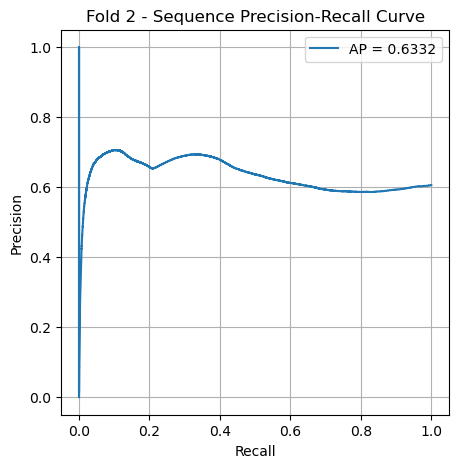


File-level Accuracy = 0.5234

File-level Classification Report:
              precision    recall  f1-score   support

           0     0.4675    0.6429    0.5414        56
           1     0.6078    0.4306    0.5041        72

    accuracy                         0.5234       128
   macro avg     0.5377    0.5367    0.5227       128
weighted avg     0.5465    0.5234    0.5204       128



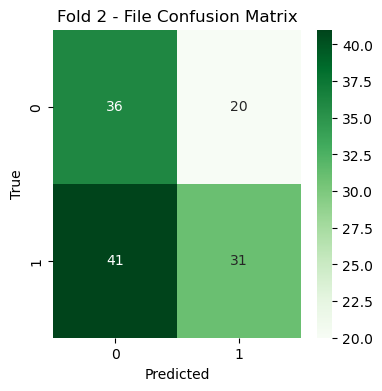

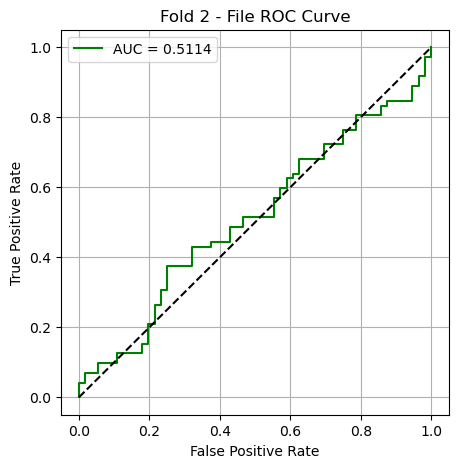

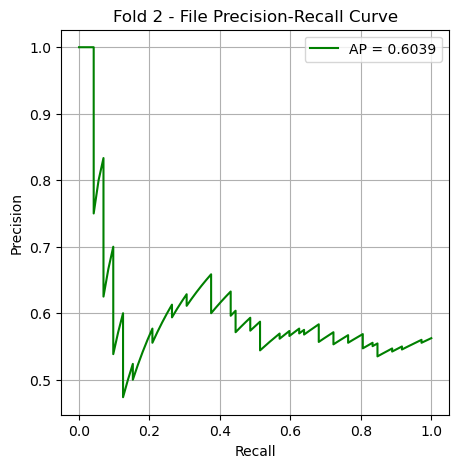


Person-level Accuracy = 0.4615

Person-level Classification Report:
              precision    recall  f1-score   support

           0     0.5000    0.7143    0.5882         7
           1     0.3333    0.1667    0.2222         6

    accuracy                         0.4615        13
   macro avg     0.4167    0.4405    0.4052        13
weighted avg     0.4231    0.4615    0.4193        13



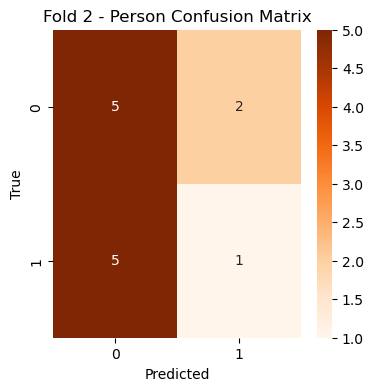

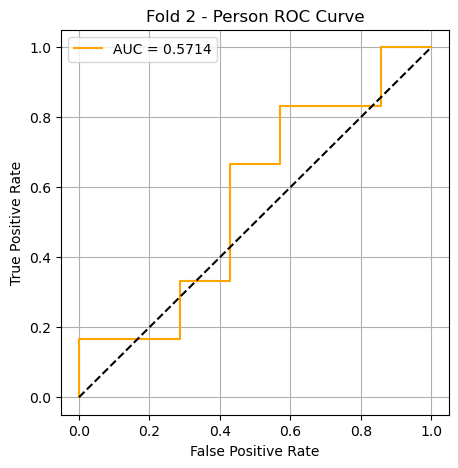

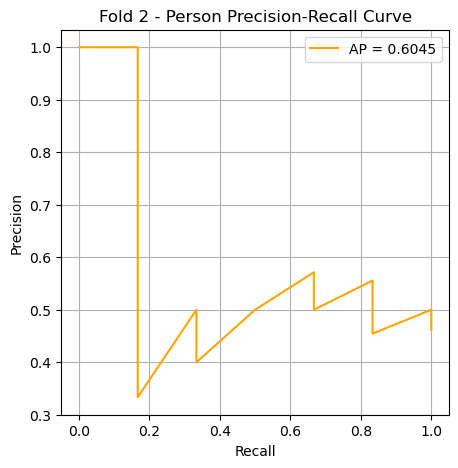


--- Fold 3 ---
Epoch 1/100
20654/20654 [==============================] - 427s 20ms/step - loss: 0.4560 - accuracy: 0.7903 - val_loss: 0.8398 - val_accuracy: 0.5694 - lr: 1.0000e-04
Epoch 2/100
20654/20654 [==============================] - 500s 24ms/step - loss: 0.3847 - accuracy: 0.8314 - val_loss: 0.8760 - val_accuracy: 0.5567 - lr: 1.0000e-04
Epoch 3/100
20653/20654 [============================>.] - ETA: 0s - loss: 0.3636 - accuracy: 0.8435Restoring model weights from the end of the best epoch: 1.

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
20654/20654 [==============================] - 502s 24ms/step - loss: 0.3636 - accuracy: 0.8435 - val_loss: 0.8915 - val_accuracy: 0.5554 - lr: 1.0000e-04
Epoch 3: early stopping

✅ Model saved to: saved_cv_models\fold_3_model.h5


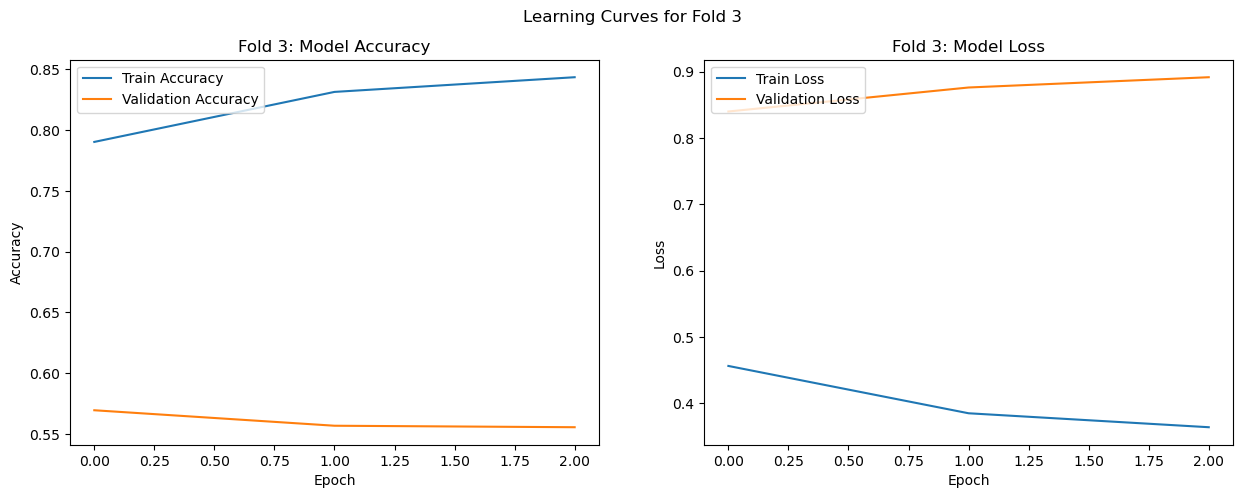

12497/12497 [==============================] - 74s 6ms/step

Sequence-level Accuracy = 0.5694

Sequence-level Classification Report:
              precision    recall  f1-score   support

           0     0.6263    0.4866    0.5477    214230
           1     0.5288    0.6650    0.5891    185644

    accuracy                         0.5694    399874
   macro avg     0.5776    0.5758    0.5684    399874
weighted avg     0.5810    0.5694    0.5669    399874



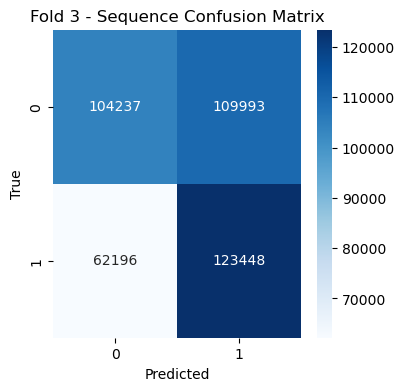

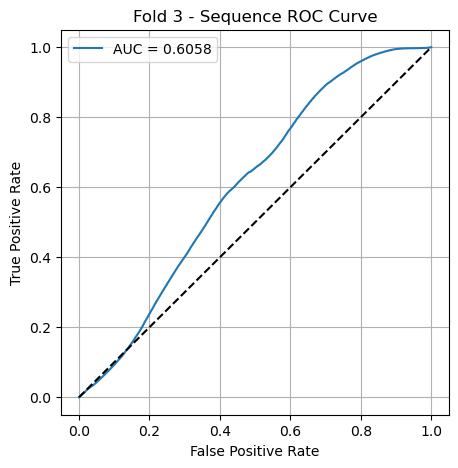

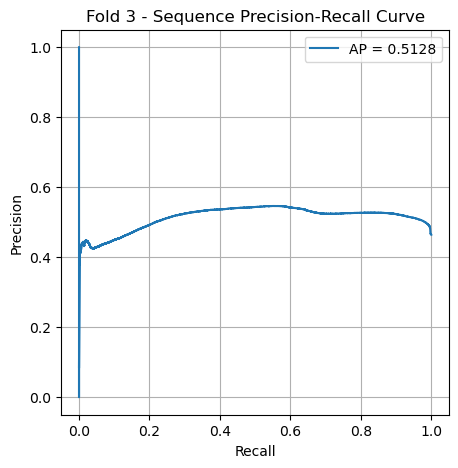


File-level Accuracy = 0.5192

File-level Classification Report:
              precision    recall  f1-score   support

           0     0.6667    0.4375    0.5283        64
           1     0.4194    0.6500    0.5098        40

    accuracy                         0.5192       104
   macro avg     0.5430    0.5437    0.5191       104
weighted avg     0.5715    0.5192    0.5212       104



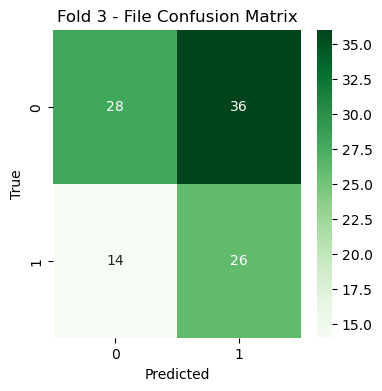

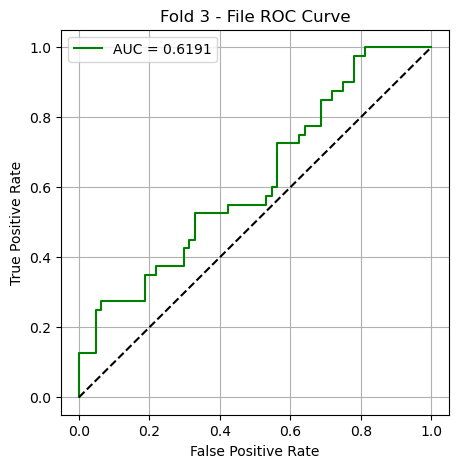

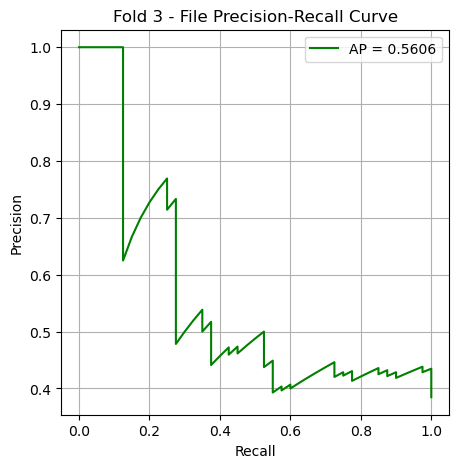


Person-level Accuracy = 0.6154

Person-level Classification Report:
              precision    recall  f1-score   support

           0     0.7143    0.6250    0.6667         8
           1     0.5000    0.6000    0.5455         5

    accuracy                         0.6154        13
   macro avg     0.6071    0.6125    0.6061        13
weighted avg     0.6319    0.6154    0.6200        13



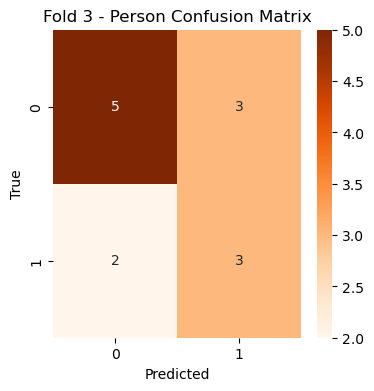

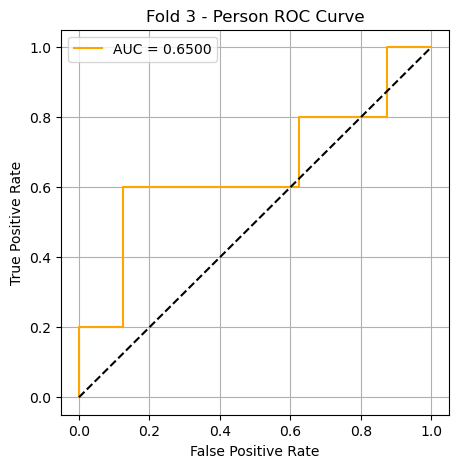

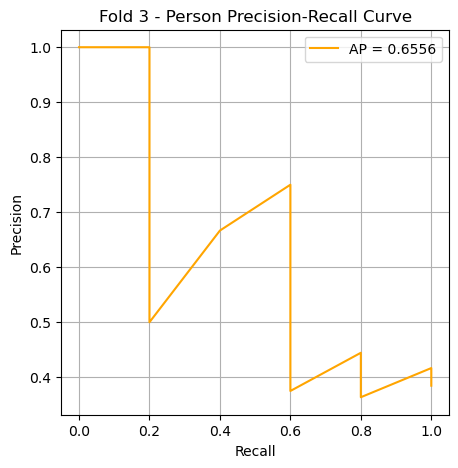


--- Fold 4 ---
Epoch 1/100
21273/21273 [==============================] - 465s 22ms/step - loss: 0.4627 - accuracy: 0.7906 - val_loss: 0.9919 - val_accuracy: 0.5444 - lr: 1.0000e-04
Epoch 2/100
21273/21273 [==============================] - 541s 25ms/step - loss: 0.3862 - accuracy: 0.8322 - val_loss: 1.1203 - val_accuracy: 0.5171 - lr: 1.0000e-04
Epoch 3/100
21271/21273 [============================>.] - ETA: 0s - loss: 0.3599 - accuracy: 0.8446Restoring model weights from the end of the best epoch: 1.

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
21273/21273 [==============================] - 553s 26ms/step - loss: 0.3599 - accuracy: 0.8446 - val_loss: 1.2198 - val_accuracy: 0.5254 - lr: 1.0000e-04
Epoch 3: early stopping

✅ Model saved to: saved_cv_models\fold_4_model.h5


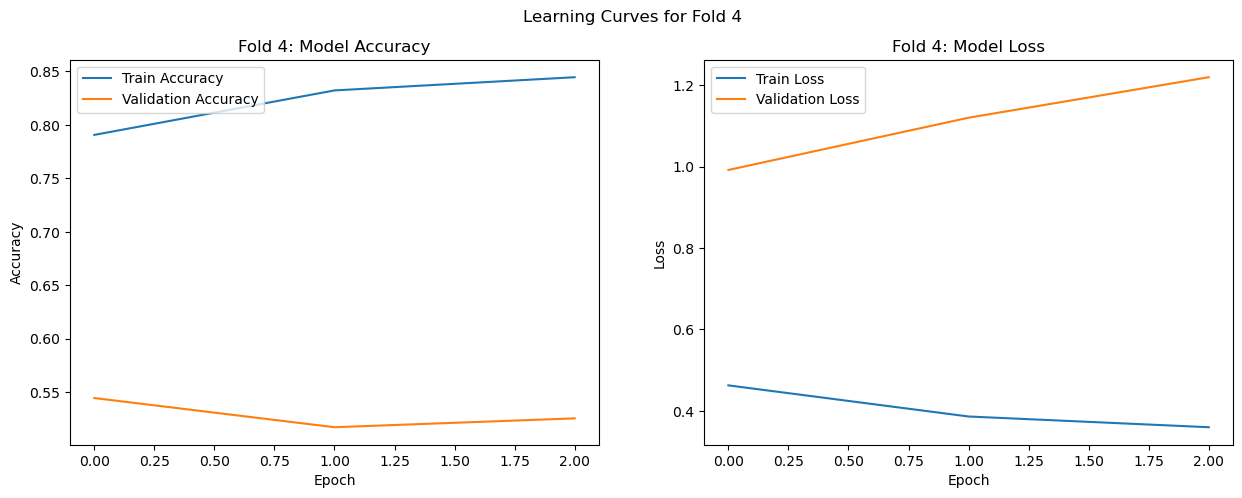

11258/11258 [==============================] - 73s 6ms/step

Sequence-level Accuracy = 0.5444

Sequence-level Classification Report:
              precision    recall  f1-score   support

           0     0.5004    0.6044    0.5475    164280
           1     0.5984    0.4941    0.5413    195958

    accuracy                         0.5444    360238
   macro avg     0.5494    0.5492    0.5444    360238
weighted avg     0.5537    0.5444    0.5441    360238



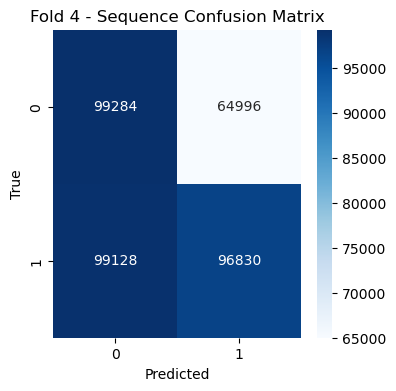

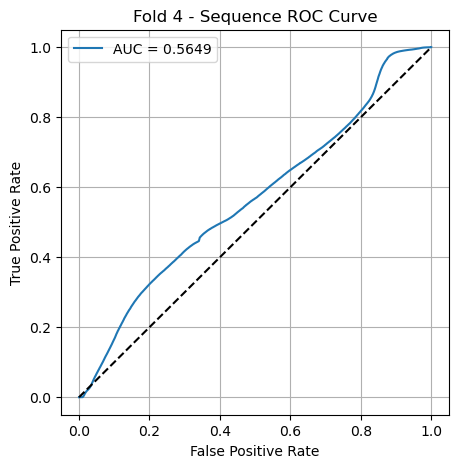

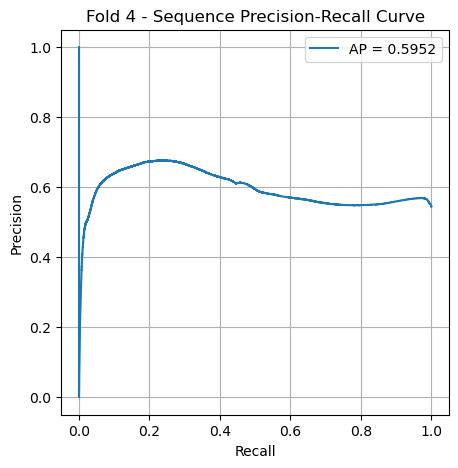


File-level Accuracy = 0.5484

File-level Classification Report:
              precision    recall  f1-score   support

           0     0.5902    0.6792    0.6316        53
           1     0.4688    0.3750    0.4167        40

    accuracy                         0.5484        93
   macro avg     0.5295    0.5271    0.5241        93
weighted avg     0.5379    0.5484    0.5391        93



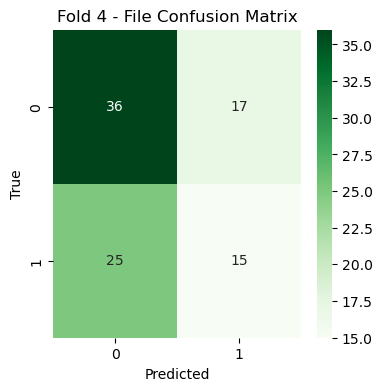

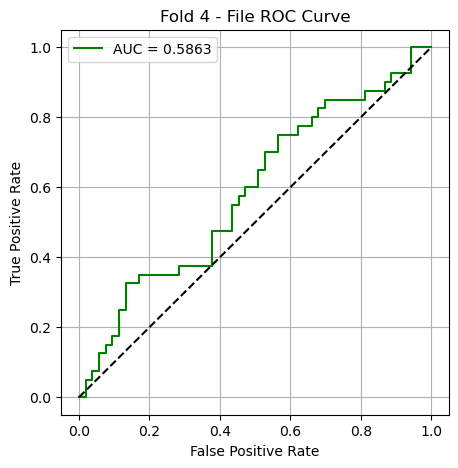

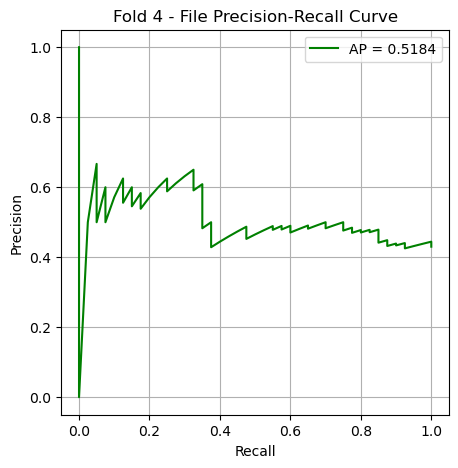


Person-level Accuracy = 0.5833

Person-level Classification Report:
              precision    recall  f1-score   support

           0     0.6250    0.7143    0.6667         7
           1     0.5000    0.4000    0.4444         5

    accuracy                         0.5833        12
   macro avg     0.5625    0.5571    0.5556        12
weighted avg     0.5729    0.5833    0.5741        12



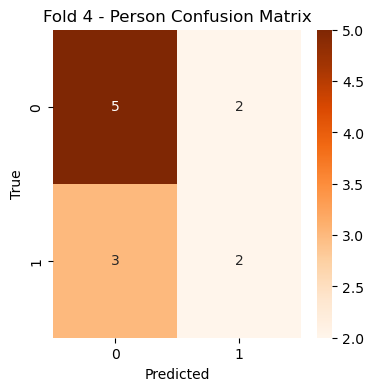

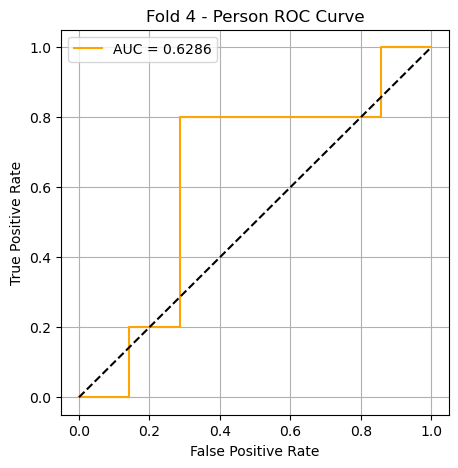

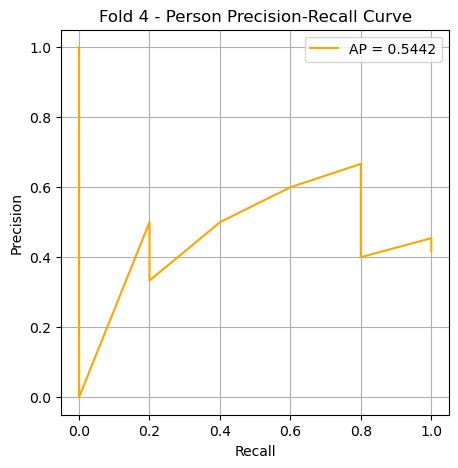


Cross-Validation Summary (Sequence-level)
Mean Accuracy: 0.5315 ± 0.0290
Mean AUC: 0.5645 ± 0.0306

Cross-Validation Summary (File-level)
Mean Accuracy: 0.5311 ± 0.0112
Mean AUC: 0.5793 ± 0.0409

Cross-Validation Summary (Person-level)
Mean Accuracy: 0.5689 ± 0.0634
Mean AUC: 0.6232 ± 0.0309

Final Comparison Table: Sequence vs File vs Person Level


,Metric,Sequence (Mean ± SD),File (Mean ± SD),Person (Mean ± SD)
0,Accuracy,0.5315 ± 0.0290,0.5311 ± 0.0112,0.5689 ± 0.0634
1,AUC,0.5645 ± 0.0306,0.5793 ± 0.0409,0.6232 ± 0.0309
2,Precision (Class 0),0.4878 ± 0.0883,0.5561 ± 0.0781,0.6161 ± 0.0763
3,Recall (Class 0),0.5973 ± 0.0678,0.5962 ± 0.0937,0.6920 ± 0.0387
4,F1 (Class 0),0.5257 ± 0.0223,0.5642 ± 0.0401,0.6471 ± 0.0340
5,Precision (Class 1),0.6084 ± 0.0511,0.5190 ± 0.0776,0.4833 ± 0.0957
6,Recall (Class 1),0.4982 ± 0.1042,0.4772 ± 0.1038,0.4167 ± 0.1607
7,F1 (Class 1),0.5366 ± 0.0376,0.4848 ± 0.0394,0.4394 ± 0.1320


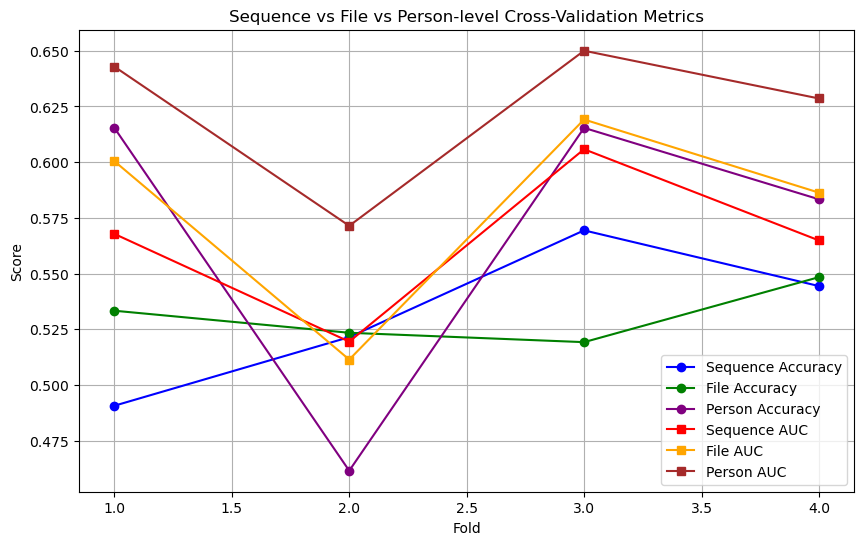

In [6]:
# =====================================
# K-FOLD CROSS-VALIDATION
# =====================================

# Map file to person
file_to_person = df_train.groupby("file_name")["Person_ID_Number"].first().to_dict()
sequence_person_ids_train = np.array([file_to_person[f] for f in sequence_file_names_train])

# Get unique persons and their corresponding labels
person_label_df = df_train.groupby("Person_ID_Number")['label'].first().reset_index()
unique_person_ids = person_label_df['Person_ID_Number'].values
person_labels = person_label_df['label'].values # <-- Labels to stratify by

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=seed)

# For sequence-level
fold_accuracies = []
fold_aucs = []
fold_reports = []

# For file-level
fold_file_accuracies = []
fold_file_aucs = []
fold_file_reports = []

# For person-level
fold_person_accuracies = []
fold_person_aucs = []
fold_person_reports = []

print("\nStarting 4-fold cross-validation...")

# Create directory to save models
import os
model_save_dir = "saved_cv_models"
os.makedirs(model_save_dir, exist_ok=True)

for fold, (train_idx, val_idx) in enumerate(skf.split(unique_person_ids, person_labels), 1):
    print(f"\n--- Fold {fold} ---")
    
    train_persons = unique_person_ids[train_idx]
    val_persons = unique_person_ids[val_idx]
    
    train_mask = np.isin(sequence_person_ids_train, train_persons)
    val_mask = np.isin(sequence_person_ids_train, val_persons)
    
    X_tr = X_train_final[train_mask]
    y_tr = y_train_seq[train_mask]
    X_val = X_train_final[val_mask]
    y_val = y_train_seq[val_mask]
    file_names_val = sequence_file_names_train[val_mask]
    person_ids_val = sequence_person_ids_train[val_mask]

    model = create_bilstm_model(input_shape=(X_tr.shape[1], X_tr.shape[2]))

    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=2,  
        mode='min',
        restore_best_weights=True, 
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=2,  
        min_lr=1e-7, 
        verbose=1
    )

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=64,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # 🆕 SAVE THE TRAINED MODEL
    model_path = os.path.join(model_save_dir, f"fold_{fold}_model.h5")
    model.save(model_path)
    print(f"\n✅ Model saved to: {model_path}")
    
    # Plot training & validation accuracy and loss for the current fold
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot training & validation accuracy values
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'Fold {fold}: Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(loc='upper left')

    # Plot training & validation loss values
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'Fold {fold}: Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(loc='upper left')

    plt.suptitle(f'Learning Curves for Fold {fold}')
    plt.show()

    # Sequence-level Evaluation
    y_val_pred_prob = model.predict(X_val)
    y_val_pred = (y_val_pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_val, y_val_pred)
    fpr, tpr, _ = roc_curve(y_val, y_val_pred_prob)
    auc_score = auc(fpr, tpr)
    
    print(f"\nSequence-level Accuracy = {acc:.4f}")
    print("\nSequence-level Classification Report:")
    print(classification_report(y_val, y_val_pred, digits=4))

    # Confusion Matrix
    cm_seq = confusion_matrix(y_val, y_val_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm_seq, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Fold {fold} - Sequence Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # ROC Curve
    plt.figure(figsize=(5,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Fold {fold} - Sequence ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_val, y_val_pred_prob)
    ap = average_precision_score(y_val, y_val_pred_prob)
    plt.figure(figsize=(5,5))
    plt.plot(rec, prec, label=f"AP = {ap:.4f}")
    plt.title(f'Fold {fold} - Sequence Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

    fold_accuracies.append(acc)
    fold_aucs.append(auc_score)

    fold_reports.append({
        "fold": fold,
        "accuracy": acc,
        "auc": auc_score,
        "classification_report": classification_report(y_val, y_val_pred, digits=4, output_dict=True)
    })

    # File-level Evaluation
    df_val = pd.DataFrame({
        "file_name": file_names_val,
        "true_label": y_val,
        "pred_label": y_val_pred,
        "pred_prob": y_val_pred_prob.flatten()
    })

    file_prob = df_val.groupby("file_name")["pred_prob"].mean()
    file_pred = (file_prob >= 0.5).astype(int)
    file_true = df_val.groupby("file_name")["true_label"].first()

    file_acc = accuracy_score(file_true, file_pred)
    fpr_file, tpr_file, _ = roc_curve(file_true, file_prob)
    file_auc = auc(fpr_file, tpr_file)
    
    print(f"\nFile-level Accuracy = {file_acc:.4f}")
    print("\nFile-level Classification Report:")
    print(classification_report(file_true, file_pred, digits=4))

    # Confusion Matrix
    cm_file = confusion_matrix(file_true, file_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm_file, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Fold {fold} - File Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # ROC Curve
    plt.figure(figsize=(5,5))
    plt.plot(fpr_file, tpr_file, label=f"AUC = {file_auc:.4f}", color='green')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Fold {fold} - File ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    # Precision-Recall Curve
    prec_file, rec_file, _ = precision_recall_curve(file_true, file_prob)
    ap_file = average_precision_score(file_true, file_prob)
    plt.figure(figsize=(5,5))
    plt.plot(rec_file, prec_file, label=f"AP = {ap_file:.4f}", color='green')
    plt.title(f'Fold {fold} - File Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

    fold_file_accuracies.append(file_acc)
    fold_file_aucs.append(file_auc)

    fold_file_reports.append({
        "fold": fold,
        "accuracy": file_acc,
        "auc": file_auc,
        "classification_report": classification_report(file_true, file_pred, digits=4, output_dict=True)
    })
    
    # Person-level Evaluation
    df_val_person = pd.DataFrame({
        "person_id": person_ids_val,
        "true_label": y_val,
        "pred_label": y_val_pred,
        "pred_prob": y_val_pred_prob.flatten()
    })

    person_prob = df_val_person.groupby("person_id")["pred_prob"].mean()
    person_pred = (person_prob >= 0.5).astype(int)
    person_true = df_val_person.groupby("person_id")["true_label"].first()

    person_acc = accuracy_score(person_true, person_pred)
    fpr_person, tpr_person, _ = roc_curve(person_true, person_prob)
    person_auc = auc(fpr_person, tpr_person)

    print(f"\nPerson-level Accuracy = {person_acc:.4f}")
    print("\nPerson-level Classification Report:")
    print(classification_report(person_true, person_pred, digits=4))

    # Confusion Matrix
    cm_person = confusion_matrix(person_true, person_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm_person, annot=True, fmt='d', cmap='Oranges')
    plt.title(f'Fold {fold} - Person Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # ROC Curve
    plt.figure(figsize=(5,5))
    plt.plot(fpr_person, tpr_person, label=f"AUC = {person_auc:.4f}", color='orange')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Fold {fold} - Person ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

    # Precision-Recall Curve
    prec_person, rec_person, _ = precision_recall_curve(person_true, person_prob)
    ap_person = average_precision_score(person_true, person_prob)
    plt.figure(figsize=(5,5))
    plt.plot(rec_person, prec_person, label=f"AP = {ap_person:.4f}", color='orange')
    plt.title(f'Fold {fold} - Person Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

    fold_person_accuracies.append(person_acc)
    fold_person_aucs.append(person_auc)

    fold_person_reports.append({
        "fold": fold,
        "accuracy": person_acc,
        "auc": person_auc,
        "classification_report": classification_report(person_true, person_pred, digits=4, output_dict=True)
    })

# Summary of CV results
print("\nCross-Validation Summary (Sequence-level)")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"Mean AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")

seq_precisions_0 = [r['classification_report']['0']['precision'] for r in fold_reports]
seq_recalls_0    = [r['classification_report']['0']['recall'] for r in fold_reports]
seq_f1s_0        = [r['classification_report']['0']['f1-score'] for r in fold_reports]

seq_precisions_1 = [r['classification_report']['1']['precision'] for r in fold_reports]
seq_recalls_1    = [r['classification_report']['1']['recall'] for r in fold_reports]
seq_f1s_1        = [r['classification_report']['1']['f1-score'] for r in fold_reports]

print("\nCross-Validation Summary (File-level)")
print(f"Mean Accuracy: {np.mean(fold_file_accuracies):.4f} ± {np.std(fold_file_accuracies):.4f}")
print(f"Mean AUC: {np.mean(fold_file_aucs):.4f} ± {np.std(fold_file_aucs):.4f}")

file_precisions_0 = [r['classification_report']['0']['precision'] for r in fold_file_reports]
file_recalls_0    = [r['classification_report']['0']['recall'] for r in fold_file_reports]
file_f1s_0        = [r['classification_report']['0']['f1-score'] for r in fold_file_reports]

file_precisions_1 = [r['classification_report']['1']['precision'] for r in fold_file_reports]
file_recalls_1    = [r['classification_report']['1']['recall'] for r in fold_file_reports]
file_f1s_1        = [r['classification_report']['1']['f1-score'] for r in fold_file_reports]

print("\nCross-Validation Summary (Person-level)")
print(f"Mean Accuracy: {np.mean(fold_person_accuracies):.4f} ± {np.std(fold_person_accuracies):.4f}")
print(f"Mean AUC: {np.mean(fold_person_aucs):.4f} ± {np.std(fold_person_aucs):.4f}")

person_precisions_0 = [r['classification_report']['0']['precision'] for r in fold_person_reports]
person_recalls_0    = [r['classification_report']['0']['recall'] for r in fold_person_reports]
person_f1s_0        = [r['classification_report']['0']['f1-score'] for r in fold_person_reports]

person_precisions_1 = [r['classification_report']['1']['precision'] for r in fold_person_reports]
person_recalls_1    = [r['classification_report']['1']['recall'] for r in fold_person_reports]
person_f1s_1        = [r['classification_report']['1']['f1-score'] for r in fold_person_reports]

# Final Comparison Table
results_table = pd.DataFrame({
    "Metric": ["Accuracy", "AUC",
               "Precision (Class 0)", "Recall (Class 0)", "F1 (Class 0)",
               "Precision (Class 1)", "Recall (Class 1)", "F1 (Class 1)"],
    "Sequence (Mean ± SD)": [
        f"{np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}",
        f"{np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}",
        f"{np.mean(seq_precisions_0):.4f} ± {np.std(seq_precisions_0):.4f}",
        f"{np.mean(seq_recalls_0):.4f} ± {np.std(seq_recalls_0):.4f}",
        f"{np.mean(seq_f1s_0):.4f} ± {np.std(seq_f1s_0):.4f}",
        f"{np.mean(seq_precisions_1):.4f} ± {np.std(seq_precisions_1):.4f}",
        f"{np.mean(seq_recalls_1):.4f} ± {np.std(seq_recalls_1):.4f}",
        f"{np.mean(seq_f1s_1):.4f} ± {np.std(seq_f1s_1):.4f}"
    ],
    "File (Mean ± SD)": [
        f"{np.mean(fold_file_accuracies):.4f} ± {np.std(fold_file_accuracies):.4f}",
        f"{np.mean(fold_file_aucs):.4f} ± {np.std(fold_file_aucs):.4f}",
        f"{np.mean(file_precisions_0):.4f} ± {np.std(file_precisions_0):.4f}",
        f"{np.mean(file_recalls_0):.4f} ± {np.std(file_recalls_0):.4f}",
        f"{np.mean(file_f1s_0):.4f} ± {np.std(file_f1s_0):.4f}",
        f"{np.mean(file_precisions_1):.4f} ± {np.std(file_precisions_1):.4f}",
        f"{np.mean(file_recalls_1):.4f} ± {np.std(file_recalls_1):.4f}",
        f"{np.mean(file_f1s_1):.4f} ± {np.std(file_f1s_1):.4f}"
    ],
    "Person (Mean ± SD)": [
        f"{np.mean(fold_person_accuracies):.4f} ± {np.std(fold_person_accuracies):.4f}",
        f"{np.mean(fold_person_aucs):.4f} ± {np.std(fold_person_aucs):.4f}",
        f"{np.mean(person_precisions_0):.4f} ± {np.std(person_precisions_0):.4f}",
        f"{np.mean(person_recalls_0):.4f} ± {np.std(person_recalls_0):.4f}",
        f"{np.mean(person_f1s_0):.4f} ± {np.std(person_f1s_0):.4f}",
        f"{np.mean(person_precisions_1):.4f} ± {np.std(person_precisions_1):.4f}",
        f"{np.mean(person_recalls_1):.4f} ± {np.std(person_recalls_1):.4f}",
        f"{np.mean(person_f1s_1):.4f} ± {np.std(person_f1s_1):.4f}"
    ]
})

print("\nFinal Comparison Table: Sequence vs File vs Person Level")
display(results_table)

# Plot CV metrics
plt.figure(figsize=(10,6))
plt.plot(range(1, len(fold_accuracies)+1), fold_accuracies, marker='o', label='Sequence Accuracy', color='blue')
plt.plot(range(1, len(fold_file_accuracies)+1), fold_file_accuracies, marker='o', label='File Accuracy', color='green')
plt.plot(range(1, len(fold_person_accuracies)+1), fold_person_accuracies, marker='o', label='Person Accuracy', color='purple')
plt.plot(range(1, len(fold_aucs)+1), fold_aucs, marker='s', label='Sequence AUC', color='red')
plt.plot(range(1, len(fold_file_aucs)+1), fold_file_aucs, marker='s', label='File AUC', color='orange')
plt.plot(range(1, len(fold_person_aucs)+1), fold_person_aucs, marker='s', label='Person AUC', color='brown')
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Sequence vs File vs Person-level Cross-Validation Metrics")
plt.legend()
plt.grid(True)
plt.show()

# Attention Weights Analysis - Cross-Validation

Extracting and analyzing attention weights across all cross-validation folds to understand which temporal patterns the model consistently focuses on when making predictions. This provides:
- **Robustness**: Averaged attention patterns across 4 folds show generalized temporal focus
- **Interpretability**: Reveals which time steps in writing sequences are most diagnostically relevant
- **Clinical Insight**: Helps identify specific moments in writing behavior that distinguish healthy from patient groups
- **Validation**: Consistency across folds confirms learned attention patterns are meaningful, not artifacts

In [7]:
# =====================================
# COLLECT ATTENTION WEIGHTS FROM ALL FOLDS (USING SAVED MODELS)
# =====================================

print("\n" + "="*80)
print("ATTENTION WEIGHTS ANALYSIS ACROSS ALL CROSS-VALIDATION FOLDS")
print("="*80)

# Store attention weights and predictions from all folds
all_fold_attention_weights = []
all_fold_y_true = []
all_fold_y_pred = []
all_fold_y_pred_prob = []

print("\nExtracting attention weights from saved models...")
print("This should be fast since models are already trained!\n")

# Re-create StratifiedKFold with SAME random_state
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import load_model
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=seed)

model_save_dir = "saved_cv_models"

for fold, (train_idx, val_idx) in enumerate(skf.split(unique_person_ids, person_labels), 1):
    print(f"Processing Fold {fold}/4...")
    
    train_persons = unique_person_ids[train_idx]
    val_persons = unique_person_ids[val_idx]
    
    train_mask = np.isin(sequence_person_ids_train, train_persons)
    val_mask = np.isin(sequence_person_ids_train, val_persons)
    
    X_val = X_train_final[val_mask]
    y_val = y_train_seq[val_mask]
    
    # 🆕 LOAD THE SAVED MODEL (instead of re-training)
    model_path = os.path.join(model_save_dir, f"fold_{fold}_model.h5")
    
    if not os.path.exists(model_path):
        print(f"❌ ERROR: Model file not found: {model_path}")
        print("Please run the cross-validation cell first to save models!")
        break
    
    # Load with custom objects (for Attention layer)
    model = load_model(model_path, custom_objects={'Attention': Attention})
    print(f"  ✅ Loaded model from: {model_path}")
    
    # Create attention extraction model
    class AttentionWithWeights(tf.keras.layers.Layer):
        """Modified Attention layer that returns both output and attention weights"""
        def __init__(self, **kwargs):
            super(AttentionWithWeights, self).__init__(**kwargs)
        
        def build(self, input_shape):
            self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
            self.b = self.add_weight(name="att_bias", shape=(1,), initializer="zeros")
            super(AttentionWithWeights, self).build(input_shape)
        
        def call(self, x):
            e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
            a = tf.keras.backend.softmax(e, axis=1)
            output = x * a
            return tf.keras.backend.sum(output, axis=1), a
    
    # Find the trained attention layer
    trained_attention_layer = None
    for layer in model.layers:
        if isinstance(layer, Attention):
            trained_attention_layer = layer
            break
    
    if trained_attention_layer is None:
        print(f"  ⚠️ WARNING: No Attention layer found in model!")
        continue
    
    # Build attention extraction model
    inputs = Input(shape=(X_val.shape[1], X_val.shape[2]))
    bilstm_layer = model.layers[1]  # Bidirectional LSTM
    x = bilstm_layer(inputs)
    dropout_layer = model.layers[2]
    x = dropout_layer(x, training=False)
    
    attention_with_weights = AttentionWithWeights()
    attention_output, attention_weights = attention_with_weights(x)
    
    attention_weights_model = Model(inputs=inputs, outputs=attention_weights)
    
    # Copy trained weights
    attention_with_weights.set_weights(trained_attention_layer.get_weights())
    
    # Extract attention weights
    fold_attention_weights = attention_weights_model.predict(X_val, batch_size=64, verbose=0)
    fold_attention_weights = fold_attention_weights.squeeze()
    
    # Ensure proper normalization per sample
    if len(fold_attention_weights.shape) == 1:
        fold_attention_weights = fold_attention_weights / fold_attention_weights.sum()
    else:
        fold_attention_weights = fold_attention_weights / fold_attention_weights.sum(axis=1, keepdims=True)
    
    # Verify normalization
    sample_sums = fold_attention_weights.sum(axis=1) if len(fold_attention_weights.shape) > 1 else [fold_attention_weights.sum()]
    assert np.allclose(sample_sums, 1.0, atol=1e-6), f"Attention weights not properly normalized in fold {fold}"
    
    # Get predictions from saved model
    y_val_pred_prob = model.predict(X_val, verbose=0)
    y_val_pred = (y_val_pred_prob > 0.5).astype(int).flatten()
    
    # Store results
    all_fold_attention_weights.append(fold_attention_weights)
    all_fold_y_true.extend(y_val)
    all_fold_y_pred.extend(y_val_pred)
    all_fold_y_pred_prob.extend(y_val_pred_prob.flatten())
    
    print(f"  Fold {fold} complete: {len(fold_attention_weights)} validation sequences")
    print(f"    Attention sum verification: min={sample_sums.min():.6f}, max={sample_sums.max():.6f}, mean={sample_sums.mean():.6f}")

# Concatenate all folds
attention_weights_all_folds = np.vstack(all_fold_attention_weights)
y_true_all_folds = np.array(all_fold_y_true)
y_pred_all_folds = np.array(all_fold_y_pred)
y_pred_prob_all_folds = np.array(all_fold_y_pred_prob)

print(f"\n✓ Attention weights extracted from all SAVED MODELS")
print(f"Total validation sequences: {len(attention_weights_all_folds)}")
print(f"Attention weights shape: {attention_weights_all_folds.shape}")

# Final verification
final_sums = attention_weights_all_folds.sum(axis=1)
print(f"\nFinal Attention Weight Normalization Verification:")
print(f"  Min sum: {final_sums.min():.8f}")
print(f"  Max sum: {final_sums.max():.8f}")
print(f"  Mean sum: {final_sums.mean():.8f}")
print(f"  All samples sum to 1.0: {np.allclose(final_sums, 1.0, atol=1e-6)}")

# Additional diagnostics
print(f"\nAttention Weight Statistics:")
print(f"  Overall mean: {attention_weights_all_folds.mean():.6f}")
print(f"  Overall std: {attention_weights_all_folds.std():.6f}")
print(f"  Expected uniform value (1/{SEQUENCE_LENGTH}): {1/SEQUENCE_LENGTH:.6f}")
print(f"  Min attention value: {attention_weights_all_folds.min():.6f}")
print(f"  Max attention value: {attention_weights_all_folds.max():.6f}")

# 🆕 Compare with original CV predictions
print(f"\n🔍 Sanity Check - Predictions Match Original CV:")
print(f"  Accuracy from saved models: {accuracy_score(y_true_all_folds, y_pred_all_folds):.4f}")
print(f"  (This should match your CV accuracy if models loaded correctly)")


ATTENTION WEIGHTS ANALYSIS ACROSS ALL CROSS-VALIDATION FOLDS

Extracting attention weights from saved models...
This should be fast since models are already trained!

Processing Fold 1/4...
  ✅ Loaded model from: saved_cv_models\fold_1_model.h5
  Fold 1 complete: 477937 validation sequences
    Attention sum verification: min=1.000000, max=1.000000, mean=1.000000
Processing Fold 2/4...
  ✅ Loaded model from: saved_cv_models\fold_2_model.h5
  Fold 2 complete: 483635 validation sequences
    Attention sum verification: min=1.000000, max=1.000000, mean=1.000000
Processing Fold 3/4...
  ✅ Loaded model from: saved_cv_models\fold_3_model.h5
  Fold 3 complete: 399874 validation sequences
    Attention sum verification: min=1.000000, max=1.000000, mean=1.000000
Processing Fold 4/4...
  ✅ Loaded model from: saved_cv_models\fold_4_model.h5
  Fold 4 complete: 360238 validation sequences
    Attention sum verification: min=1.000000, max=1.000000, mean=1.000000

✓ Attention weights extracted from 


FOCUSED ATTENTION ANALYSIS: HEALTHY VS PATIENT

📊 TOP 5 TIME STEPS WITH LARGEST ATTENTION DIFFERENCE:
1. Time Step 20: Healthy=0.0576, Patient=0.0678, Diff=+0.0102
2. Time Step 19: Healthy=0.0555, Patient=0.0634, Diff=+0.0079
3. Time Step 18: Healthy=0.0533, Patient=0.0589, Diff=+0.0057
4. Time Step  2: Healthy=0.0560, Patient=0.0521, Diff=-0.0040
5. Time Step  3: Healthy=0.0545, Patient=0.0506, Diff=-0.0039

📊 TOP 5 TIME STEPS MOST ATTENDED BY PATIENTS:
1. Time Step 20: Patient=0.0678 (vs Uniform=0.0500, +1.8%)
2. Time Step 19: Patient=0.0634 (vs Uniform=0.0500, +1.3%)
3. Time Step 18: Patient=0.0589 (vs Uniform=0.0500, +0.9%)
4. Time Step 10: Patient=0.0436 (vs Uniform=0.0500, +-0.6%)
5. Time Step  9: Patient=0.0437 (vs Uniform=0.0500, +-0.6%)


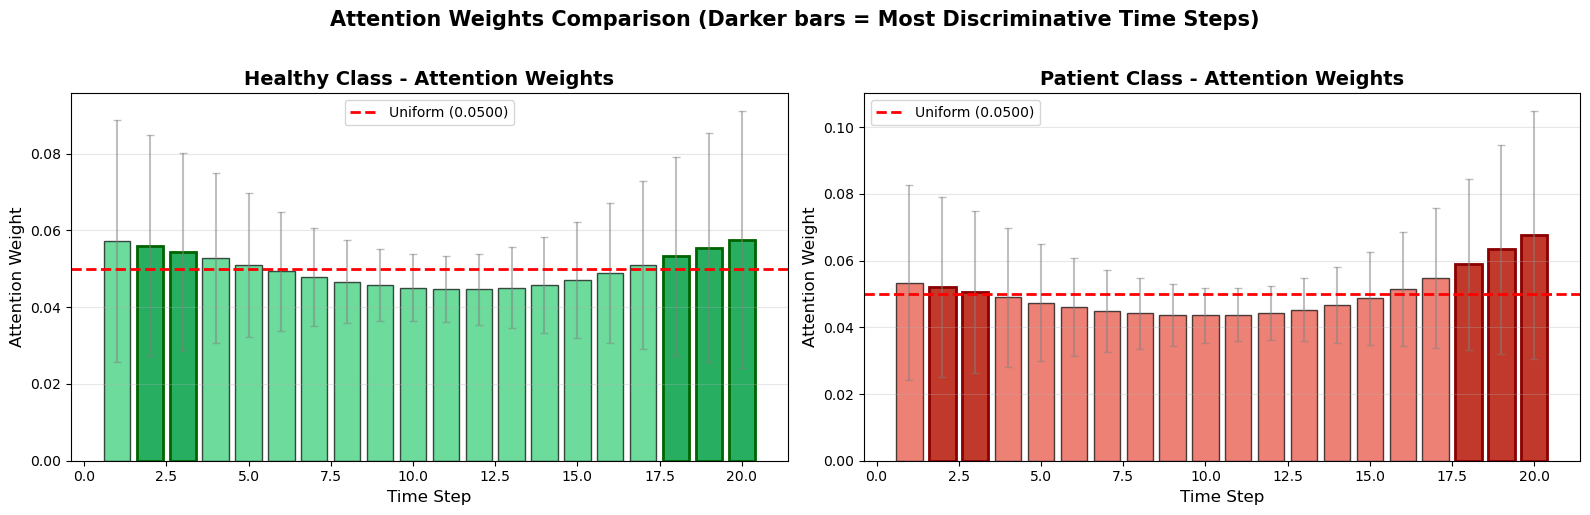

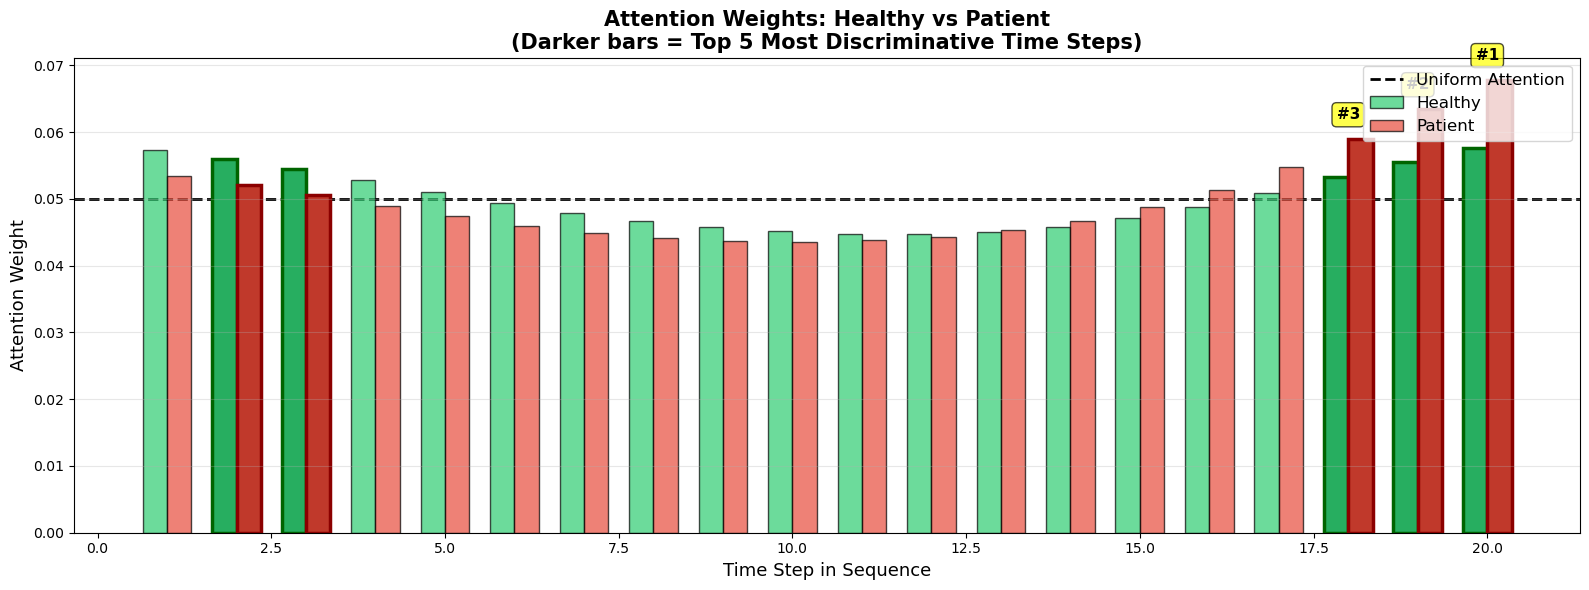

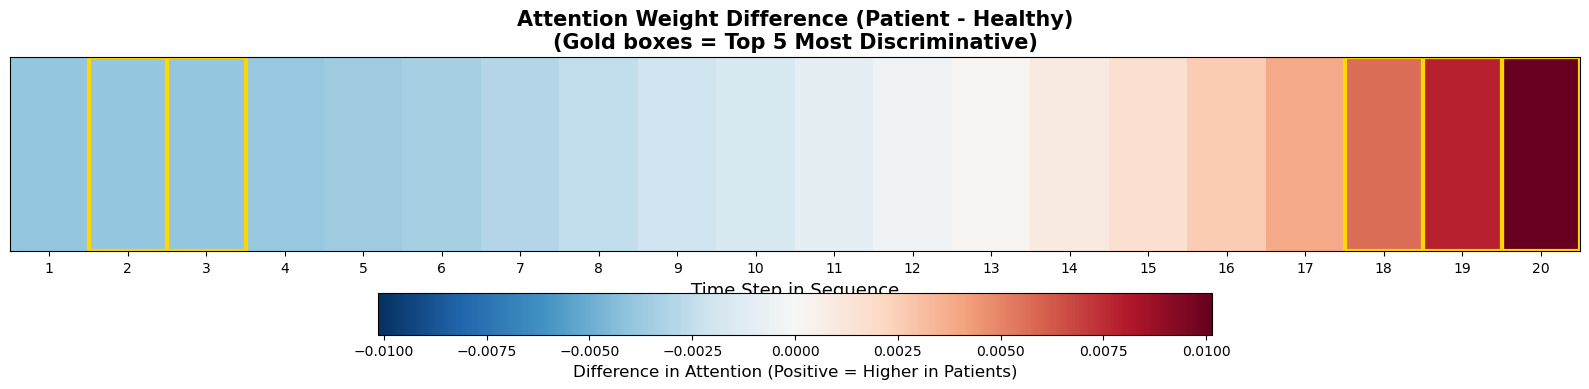

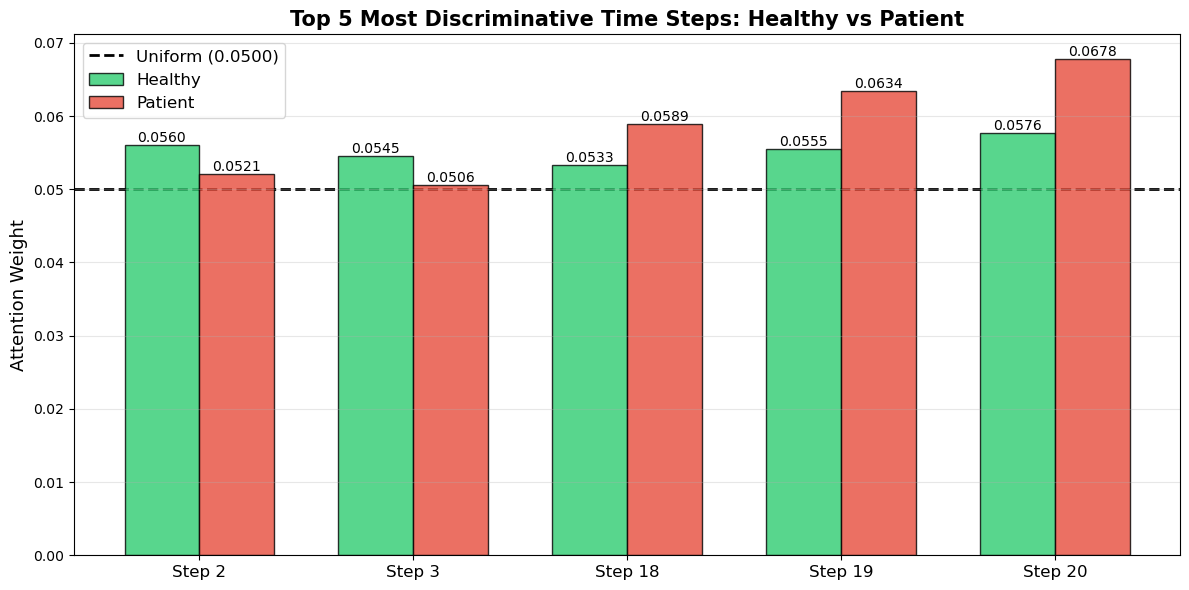


ATTENTION ANALYSIS SUMMARY

📈 OVERALL STATISTICS:
  Healthy - Mean: 0.0500, Std: 0.0044
  Patient - Mean: 0.0500, Std: 0.0067
  Uniform Baseline: 0.0500

🎯 ATTENTION CONCENTRATION:
  Healthy max/uniform ratio: 1.15x
  Patient max/uniform ratio: 1.36x

📊 STATISTICAL SIGNIFICANCE (Top 5 Time Steps):
  Step 20: t=-185.602, p=0.0000 ***
  Step 19: t=-167.004, p=0.0000 ***
  Step 18: t=-143.113, p=0.0000 ***
  Step 2: t=+92.630, p=0.0000 ***
  Step 3: t=+102.603, p=0.0000 ***

FOCUSED ATTENTION ANALYSIS COMPLETE


In [8]:
# =====================================
# FOCUSED ATTENTION ANALYSIS: HEALTHY VS PATIENT (KEY TIME STEPS)
# =====================================

print("\n" + "="*80)
print("FOCUSED ATTENTION ANALYSIS: HEALTHY VS PATIENT")
print("="*80)

# Calculate average attention by class
attention_healthy = attention_weights_all_folds[y_true_all_folds == 0]
attention_patient = attention_weights_all_folds[y_true_all_folds == 1]

avg_attention_healthy = attention_healthy.mean(axis=0)
avg_attention_patient = attention_patient.mean(axis=0)
std_attention_healthy = attention_healthy.std(axis=0)
std_attention_patient = attention_patient.std(axis=0)

# Calculate difference and identify important time steps
attention_diff = avg_attention_patient - avg_attention_healthy
uniform_baseline = 1 / SEQUENCE_LENGTH

# Identify time steps that deviate significantly from uniform
healthy_importance = np.abs(avg_attention_healthy - uniform_baseline)
patient_importance = np.abs(avg_attention_patient - uniform_baseline)
diff_importance = np.abs(attention_diff)

# Get top 5 most important time steps based on difference
top_k = 5
top_diff_indices = np.argsort(diff_importance)[-top_k:][::-1]
top_patient_indices = np.argsort(patient_importance)[-top_k:][::-1]

print(f"\n📊 TOP {top_k} TIME STEPS WITH LARGEST ATTENTION DIFFERENCE:")
print("=" * 70)
for rank, idx in enumerate(top_diff_indices, 1):
    time_step = idx + 1
    print(f"{rank}. Time Step {time_step:2d}: "
          f"Healthy={avg_attention_healthy[idx]:.4f}, "
          f"Patient={avg_attention_patient[idx]:.4f}, "
          f"Diff={attention_diff[idx]:+.4f}")

print(f"\n📊 TOP {top_k} TIME STEPS MOST ATTENDED BY PATIENTS:")
print("=" * 70)
for rank, idx in enumerate(top_patient_indices, 1):
    time_step = idx + 1
    print(f"{rank}. Time Step {time_step:2d}: "
          f"Patient={avg_attention_patient[idx]:.4f} "
          f"(vs Uniform={uniform_baseline:.4f}, "
          f"+{(avg_attention_patient[idx]-uniform_baseline)*100:.1f}%)")

# =====================================
# VISUALIZATION 1: SIDE-BY-SIDE COMPARISON (ALL TIME STEPS)
# =====================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Healthy attention
x = np.arange(1, SEQUENCE_LENGTH + 1)
axes[0].bar(x, avg_attention_healthy, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].errorbar(x, avg_attention_healthy, yerr=std_attention_healthy, 
                 fmt='none', ecolor='gray', capsize=3, alpha=0.5)
axes[0].axhline(uniform_baseline, color='red', linestyle='--', 
                linewidth=2, label=f'Uniform ({uniform_baseline:.4f})')
# Highlight top important time steps
for idx in top_diff_indices:
    axes[0].bar(idx + 1, avg_attention_healthy[idx], 
                color='#27ae60', alpha=1.0, edgecolor='darkgreen', linewidth=2)
axes[0].set_title('Healthy Class - Attention Weights', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Time Step', fontsize=12)
axes[0].set_ylabel('Attention Weight', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Patient attention
axes[1].bar(x, avg_attention_patient, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].errorbar(x, avg_attention_patient, yerr=std_attention_patient, 
                 fmt='none', ecolor='gray', capsize=3, alpha=0.5)
axes[1].axhline(uniform_baseline, color='red', linestyle='--', 
                linewidth=2, label=f'Uniform ({uniform_baseline:.4f})')
# Highlight top important time steps
for idx in top_diff_indices:
    axes[1].bar(idx + 1, avg_attention_patient[idx], 
                color='#c0392b', alpha=1.0, edgecolor='darkred', linewidth=2)
axes[1].set_title('Patient Class - Attention Weights', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Time Step', fontsize=12)
axes[1].set_ylabel('Attention Weight', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Attention Weights Comparison (Darker bars = Most Discriminative Time Steps)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =====================================
# VISUALIZATION 2: OVERLAPPING COMPARISON WITH SIGNIFICANCE MARKERS
# =====================================

fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(1, SEQUENCE_LENGTH + 1)
width = 0.35

# Plot bars
bars_healthy = ax.bar(x - width/2, avg_attention_healthy, width, 
                      label='Healthy', color='#2ecc71', alpha=0.7, edgecolor='black')
bars_patient = ax.bar(x + width/2, avg_attention_patient, width, 
                      label='Patient', color='#e74c3c', alpha=0.7, edgecolor='black')

# Highlight important time steps
for idx in top_diff_indices:
    bars_healthy[idx].set_color('#27ae60')
    bars_healthy[idx].set_alpha(1.0)
    bars_healthy[idx].set_edgecolor('darkgreen')
    bars_healthy[idx].set_linewidth(2.5)
    
    bars_patient[idx].set_color('#c0392b')
    bars_patient[idx].set_alpha(1.0)
    bars_patient[idx].set_edgecolor('darkred')
    bars_patient[idx].set_linewidth(2.5)

# Add uniform baseline
ax.axhline(uniform_baseline, color='black', linestyle='--', 
           linewidth=2, label='Uniform Attention', zorder=0)

# Mark top important time steps with annotations
for rank, idx in enumerate(top_diff_indices[:3], 1):  # Show top 3
    time_step = idx + 1
    max_height = max(avg_attention_healthy[idx], avg_attention_patient[idx])
    ax.annotate(f'#{rank}', 
                xy=(time_step, max_height + 0.003),
                ha='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_title('Attention Weights: Healthy vs Patient\n(Darker bars = Top 5 Most Discriminative Time Steps)', 
             fontweight='bold', fontsize=15)
ax.set_xlabel('Time Step in Sequence', fontsize=13)
ax.set_ylabel('Attention Weight', fontsize=13)
ax.legend(loc='upper right', fontsize=12)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# =====================================
# VISUALIZATION 3: ATTENTION DIFFERENCE HEATMAP (FOCUSED)
# =====================================

fig, ax = plt.subplots(figsize=(16, 4))

# Create color map centered at 0
vmax = max(abs(attention_diff.min()), abs(attention_diff.max()))
im = ax.imshow([attention_diff], cmap='RdBu_r', aspect='auto', 
               vmin=-vmax, vmax=vmax)

# Highlight important time steps
for idx in top_diff_indices:
    ax.add_patch(plt.Rectangle((idx - 0.5, -0.5), 1, 1, 
                               fill=False, edgecolor='gold', linewidth=3))

ax.set_yticks([])
ax.set_xticks(range(SEQUENCE_LENGTH))
ax.set_xticklabels(range(1, SEQUENCE_LENGTH + 1))
ax.set_xlabel('Time Step in Sequence', fontsize=13)
ax.set_title('Attention Weight Difference (Patient - Healthy)\n(Gold boxes = Top 5 Most Discriminative)', 
             fontweight='bold', fontsize=15)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.15, shrink=0.8)
cbar.set_label('Difference in Attention (Positive = Higher in Patients)', fontsize=12)
plt.tight_layout()
plt.show()

# =====================================
# VISUALIZATION 4: FOCUSED BAR CHART (TOP TIME STEPS ONLY)
# =====================================

fig, ax = plt.subplots(figsize=(12, 6))

# Focus on top important time steps
top_indices_sorted = sorted(top_diff_indices)
x_pos = np.arange(len(top_indices_sorted))
width = 0.35

healthy_vals = [avg_attention_healthy[i] for i in top_indices_sorted]
patient_vals = [avg_attention_patient[i] for i in top_indices_sorted]
labels = [f'Step {i+1}' for i in top_indices_sorted]

bars1 = ax.bar(x_pos - width/2, healthy_vals, width, 
               label='Healthy', color='#2ecc71', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, patient_vals, width, 
               label='Patient', color='#e74c3c', alpha=0.8, edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

ax.axhline(uniform_baseline, color='black', linestyle='--', 
           linewidth=2, label=f'Uniform ({uniform_baseline:.4f})', zorder=0)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Attention Weight', fontsize=13)
ax.set_title(f'Top {top_k} Most Discriminative Time Steps: Healthy vs Patient', 
             fontweight='bold', fontsize=15)
ax.legend(fontsize=12)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# =====================================
# SUMMARY STATISTICS
# =====================================

print("\n" + "="*80)
print("ATTENTION ANALYSIS SUMMARY")
print("="*80)

print(f"\n📈 OVERALL STATISTICS:")
print(f"  Healthy - Mean: {avg_attention_healthy.mean():.4f}, Std: {avg_attention_healthy.std():.4f}")
print(f"  Patient - Mean: {avg_attention_patient.mean():.4f}, Std: {avg_attention_patient.std():.4f}")
print(f"  Uniform Baseline: {uniform_baseline:.4f}")

print(f"\n🎯 ATTENTION CONCENTRATION:")
# Measure how concentrated the attention is (higher = more focused)
healthy_concentration = np.max(avg_attention_healthy) / uniform_baseline
patient_concentration = np.max(avg_attention_patient) / uniform_baseline
print(f"  Healthy max/uniform ratio: {healthy_concentration:.2f}x")
print(f"  Patient max/uniform ratio: {patient_concentration:.2f}x")

print(f"\n📊 STATISTICAL SIGNIFICANCE (Top {top_k} Time Steps):")
from scipy import stats
for rank, idx in enumerate(top_diff_indices, 1):
    t_stat, p_value = stats.ttest_ind(attention_healthy[:, idx], 
                                       attention_patient[:, idx])
    print(f"  Step {idx+1}: t={t_stat:+.3f}, p={p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

print("\n" + "="*80)
print("FOCUSED ATTENTION ANALYSIS COMPLETE")
print("="*80)


📊 Creating Heatmap Visualizations...


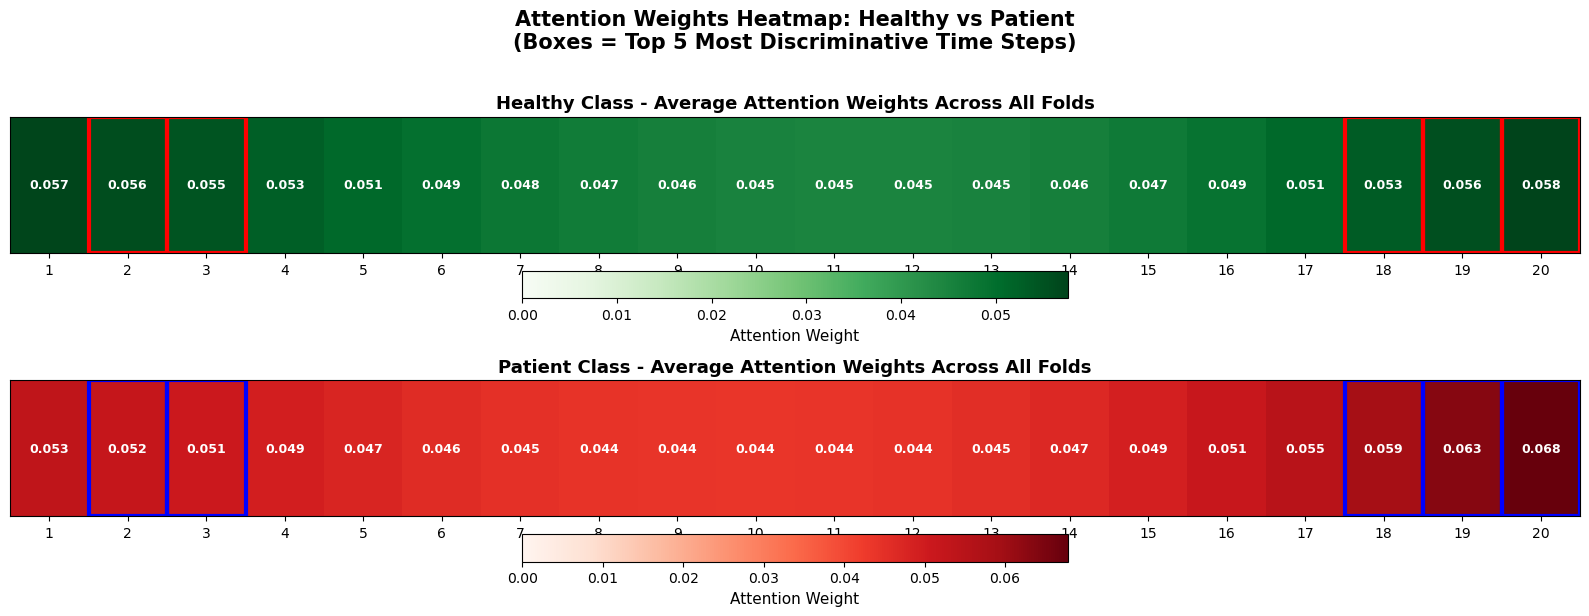

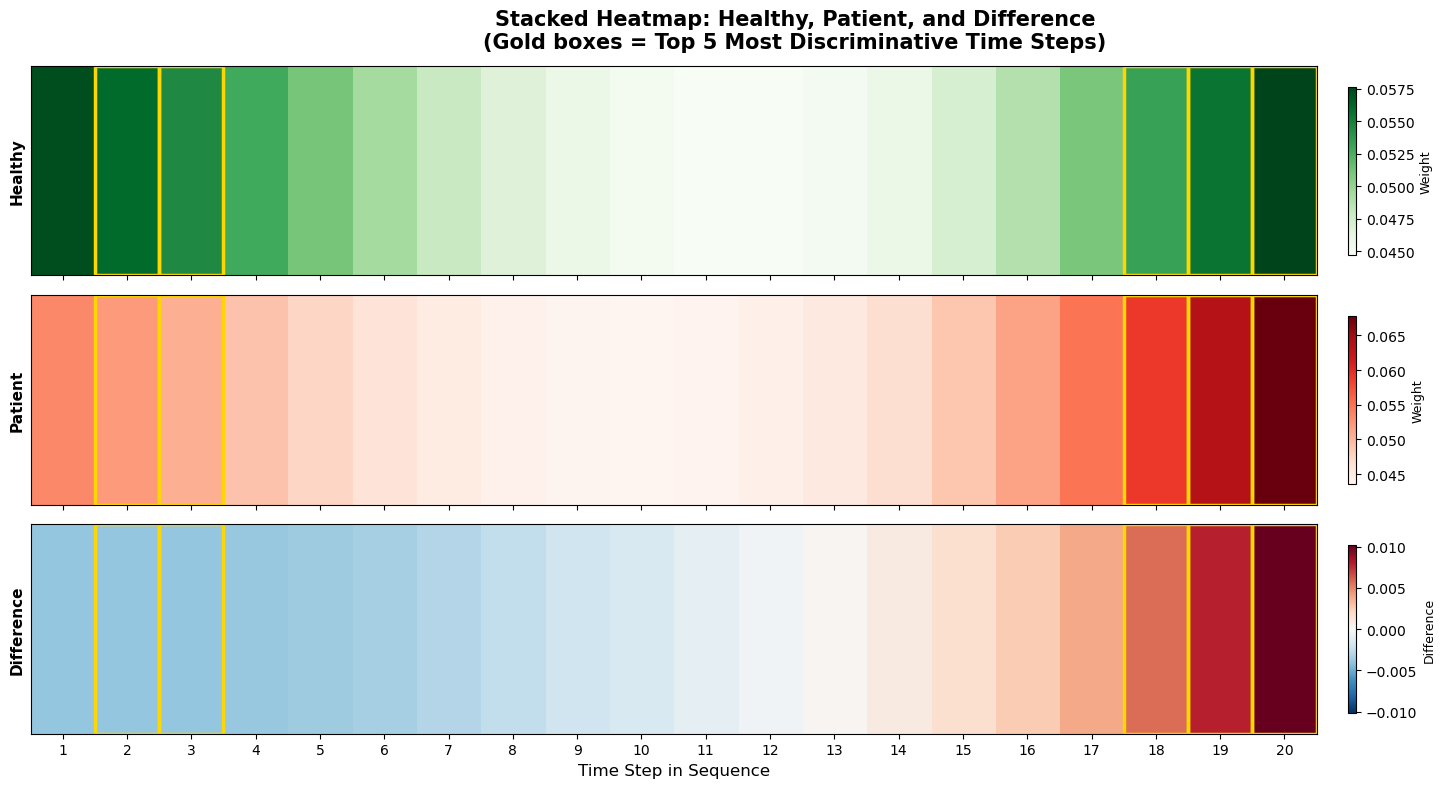

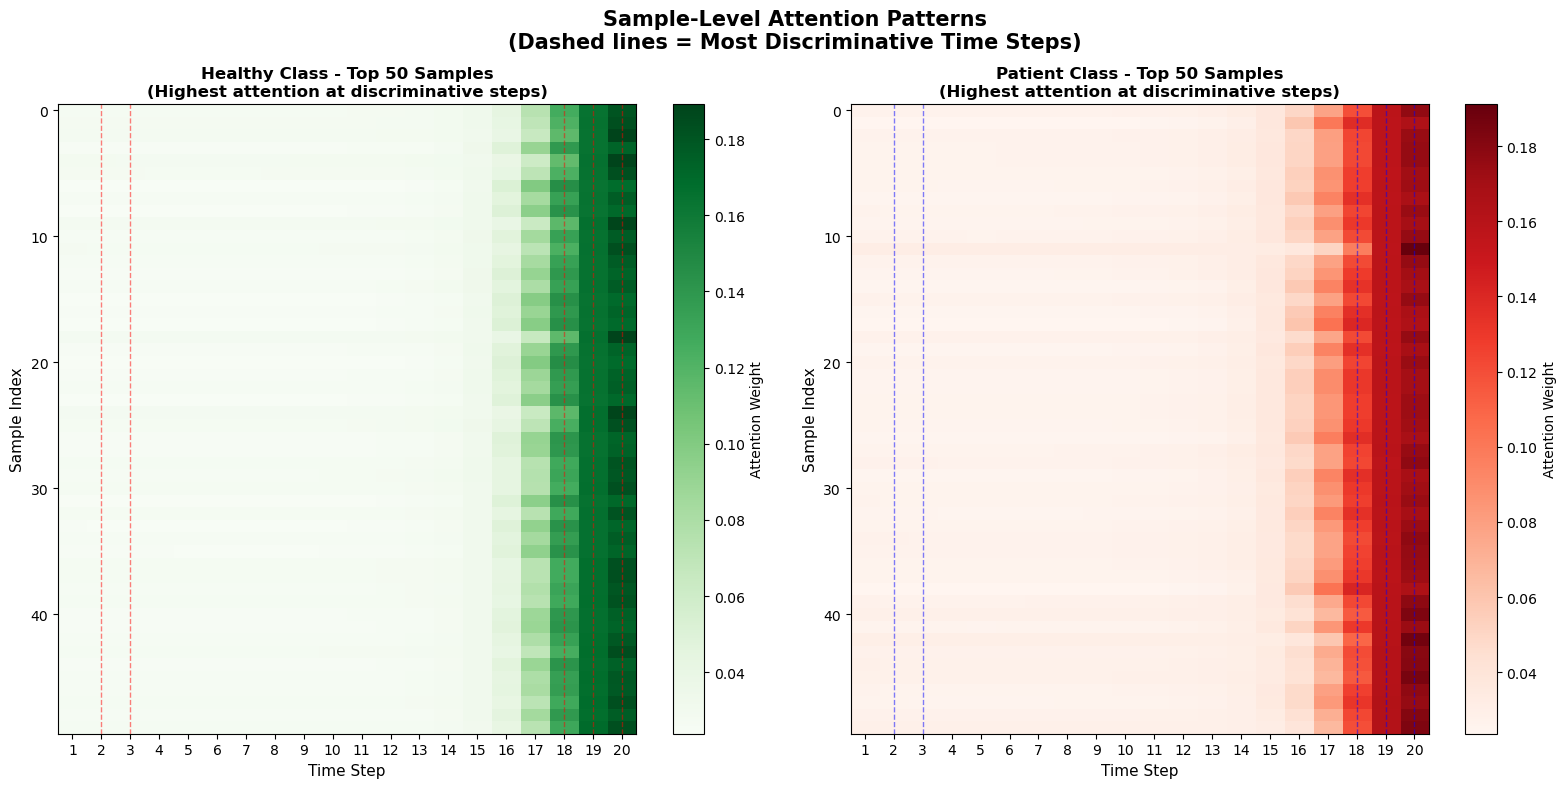


✅ Heatmap visualizations complete!


In [9]:
# =====================================
# VISUALIZATION 5: HEATMAP COMPARISON - HEALTHY VS PATIENT
# =====================================

print("\n📊 Creating Heatmap Visualizations...")

# Create a 2-row heatmap comparing healthy and patient attention patterns
fig, axes = plt.subplots(2, 1, figsize=(16, 6))

# Healthy class heatmap
im1 = axes[0].imshow([avg_attention_healthy], cmap='Greens', aspect='auto', vmin=0, vmax=avg_attention_healthy.max())
axes[0].set_yticks([])
axes[0].set_xticks(range(SEQUENCE_LENGTH))
axes[0].set_xticklabels(range(1, SEQUENCE_LENGTH + 1))
axes[0].set_title('Healthy Class - Average Attention Weights Across All Folds', fontweight='bold', fontsize=13)

# Add value annotations on heatmap
for i in range(SEQUENCE_LENGTH):
    text_color = 'white' if avg_attention_healthy[i] > avg_attention_healthy.max() * 0.5 else 'black'
    axes[0].text(i, 0, f'{avg_attention_healthy[i]:.3f}', 
                ha='center', va='center', fontsize=9, color=text_color, fontweight='bold')

# Highlight top discriminative time steps
for idx in top_diff_indices:
    axes[0].add_patch(plt.Rectangle((idx - 0.5, -0.5), 1, 1, 
                                   fill=False, edgecolor='red', linewidth=3))

cbar1 = plt.colorbar(im1, ax=axes[0], orientation='horizontal', pad=0.1, shrink=0.8)
cbar1.set_label('Attention Weight', fontsize=11)

# Patient class heatmap
im2 = axes[1].imshow([avg_attention_patient], cmap='Reds', aspect='auto', vmin=0, vmax=avg_attention_patient.max())
axes[1].set_yticks([])
axes[1].set_xticks(range(SEQUENCE_LENGTH))
axes[1].set_xticklabels(range(1, SEQUENCE_LENGTH + 1))
axes[1].set_xlabel('Time Step in Sequence', fontsize=12)
axes[1].set_title('Patient Class - Average Attention Weights Across All Folds', fontweight='bold', fontsize=13)

# Add value annotations on heatmap
for i in range(SEQUENCE_LENGTH):
    text_color = 'white' if avg_attention_patient[i] > avg_attention_patient.max() * 0.5 else 'black'
    axes[1].text(i, 0, f'{avg_attention_patient[i]:.3f}', 
                ha='center', va='center', fontsize=9, color=text_color, fontweight='bold')

# Highlight top discriminative time steps
for idx in top_diff_indices:
    axes[1].add_patch(plt.Rectangle((idx - 0.5, -0.5), 1, 1, 
                                   fill=False, edgecolor='blue', linewidth=3))

cbar2 = plt.colorbar(im2, ax=axes[1], orientation='horizontal', pad=0.1, shrink=0.8)
cbar2.set_label('Attention Weight', fontsize=11)

plt.suptitle('Attention Weights Heatmap: Healthy vs Patient\n(Boxes = Top 5 Most Discriminative Time Steps)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =====================================
# VISUALIZATION 6: COMBINED HEATMAP WITH DIFFERENCE
# =====================================

fig, axes = plt.subplots(3, 1, figsize=(16, 8))

# Healthy class
im1 = axes[0].imshow([avg_attention_healthy], cmap='Greens', aspect='auto')
axes[0].set_yticks([])
axes[0].set_xticks(range(SEQUENCE_LENGTH))
axes[0].set_xticklabels([])
axes[0].set_ylabel('Healthy', fontsize=11, fontweight='bold')
for idx in top_diff_indices:
    axes[0].add_patch(plt.Rectangle((idx - 0.5, -0.5), 1, 1, 
                                   fill=False, edgecolor='gold', linewidth=2.5))
cbar1 = plt.colorbar(im1, ax=axes[0], orientation='vertical', pad=0.02, shrink=0.8)
cbar1.set_label('Weight', fontsize=9)

# Patient class
im2 = axes[1].imshow([avg_attention_patient], cmap='Reds', aspect='auto')
axes[1].set_yticks([])
axes[1].set_xticks(range(SEQUENCE_LENGTH))
axes[1].set_xticklabels([])
axes[1].set_ylabel('Patient', fontsize=11, fontweight='bold')
for idx in top_diff_indices:
    axes[1].add_patch(plt.Rectangle((idx - 0.5, -0.5), 1, 1, 
                                   fill=False, edgecolor='gold', linewidth=2.5))
cbar2 = plt.colorbar(im2, ax=axes[1], orientation='vertical', pad=0.02, shrink=0.8)
cbar2.set_label('Weight', fontsize=9)

# Difference (Patient - Healthy)
vmax = max(abs(attention_diff.min()), abs(attention_diff.max()))
im3 = axes[2].imshow([attention_diff], cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
axes[2].set_yticks([])
axes[2].set_xticks(range(SEQUENCE_LENGTH))
axes[2].set_xticklabels(range(1, SEQUENCE_LENGTH + 1), fontsize=10)
axes[2].set_xlabel('Time Step in Sequence', fontsize=12)
axes[2].set_ylabel('Difference', fontsize=11, fontweight='bold')
for idx in top_diff_indices:
    axes[2].add_patch(plt.Rectangle((idx - 0.5, -0.5), 1, 1, 
                                   fill=False, edgecolor='gold', linewidth=2.5))
cbar3 = plt.colorbar(im3, ax=axes[2], orientation='vertical', pad=0.02, shrink=0.8)
cbar3.set_label('Difference', fontsize=9)

plt.suptitle('Stacked Heatmap: Healthy, Patient, and Difference\n(Gold boxes = Top 5 Most Discriminative Time Steps)', 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =====================================
# VISUALIZATION 7: SAMPLE-LEVEL HEATMAP (TOP SAMPLES)
# =====================================

# Select top samples with highest and lowest attention at discriminative time steps
n_samples_to_show = 50

# For healthy class
healthy_attention_at_top_steps = attention_healthy[:, top_diff_indices].mean(axis=1)
top_healthy_indices = np.argsort(healthy_attention_at_top_steps)[-n_samples_to_show:]

# For patient class
patient_attention_at_top_steps = attention_patient[:, top_diff_indices].mean(axis=1)
top_patient_indices = np.argsort(patient_attention_at_top_steps)[-n_samples_to_show:]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Healthy samples
im1 = axes[0].imshow(attention_healthy[top_healthy_indices], cmap='Greens', aspect='auto')
axes[0].set_title(f'Healthy Class - Top {n_samples_to_show} Samples\n(Highest attention at discriminative steps)', 
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Time Step', fontsize=11)
axes[0].set_ylabel('Sample Index', fontsize=11)
axes[0].set_xticks(range(SEQUENCE_LENGTH))
axes[0].set_xticklabels(range(1, SEQUENCE_LENGTH + 1))
# Mark discriminative time steps
for idx in top_diff_indices:
    axes[0].axvline(idx, color='red', linestyle='--', alpha=0.5, linewidth=1)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Attention Weight', fontsize=10)

# Patient samples
im2 = axes[1].imshow(attention_patient[top_patient_indices], cmap='Reds', aspect='auto')
axes[1].set_title(f'Patient Class - Top {n_samples_to_show} Samples\n(Highest attention at discriminative steps)', 
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Time Step', fontsize=11)
axes[1].set_ylabel('Sample Index', fontsize=11)
axes[1].set_xticks(range(SEQUENCE_LENGTH))
axes[1].set_xticklabels(range(1, SEQUENCE_LENGTH + 1))
# Mark discriminative time steps
for idx in top_diff_indices:
    axes[1].axvline(idx, color='blue', linestyle='--', alpha=0.5, linewidth=1)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Attention Weight', fontsize=10)

plt.suptitle('Sample-Level Attention Patterns\n(Dashed lines = Most Discriminative Time Steps)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Heatmap visualizations complete!")